# Анализ лояльности пользователей Яндекс Афиши

**Автор**: Гревцев Данил

### Цели и задачи проекта

В данном проекте необходимо извлечь данные из БД и проанализировать их при помощи языка программирования Python. Нам нужно провести исследовательский анализ данных, чтобы определить какие пользователи с большой вероятностью совершают повторные покупки, т.е. определить связь между тем как пользователети совершают заказы и признаками датафрейма, обнаружить данные, которые коррелируют.

### Содержимое проекта

* [1. Загрузка данных и их предобработка](#1.-Загрузка-данных-и-их-предобработка)
* [2. Предобработка данных](#2.-Предобработка-данных)
* [3. Создание профиля пользователя](#3.-Создание-профиля-пользователя)
* [4. Исследовательский анализ данных](#4.-Исследовательский-анализ-данных)
* [5. Общий вывод и рекомендации](#5.-Общий-вывод-и-рекомендации)
* [6. Финализация проекта и публикация в Git](#6.-Финализация-проекта-и-публикация-в-Git)

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
# Загрузим сторонние библиотеки
!pip install sqlalchemy
!pip install psycopg2
!pip install phik

In [4]:
# Добавим сторонние библиотеки в проект
import pandas as pd
from sqlalchemy import create_engilsne
import matplotlib.pyplot as plt
import math
from phik import phik_matrix
import numpy as np
import seaborn as sns

### Замечание
Данные будем загружать из кода, но файл `.env` создан.

In [5]:
# Конфигурация для подключения
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [6]:
# Структура для подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [7]:
# Создаем соединение
engine = create_engine(connection_string)

In [8]:
# Формируем sql-запрос

# Изменим название второго event_id на event_id_code, чтобы не было дубликатов в названиях признаков

query = '''
SELECT 
      user_id,
      device_type_canonical,
      order_id,
      created_dt_msk AS order_dt,
      created_ts_msk AS order_ts,
      currency_code,
      revenue,
      tickets_count,
      EXTRACT(DAY FROM (created_dt_msk - LAG(created_dt_msk, 1, NULL) OVER(PARTITION BY user_id ORDER BY created_dt_msk))) AS days_since_prev,
      event_id,
      event_name_code AS event_id_code,
      event_type_main,
      service_name,
      region_name,
      city_name
FROM afisha.purchases
LEFT JOIN afisha.events USING(event_id)
LEFT JOIN afisha.city USING(city_id)
LEFT JOIN afisha.regions USING(region_id)
WHERE ((device_type_canonical = 'mobile') OR (device_type_canonical = 'desktop')) AND (event_type_main <> 'фильм')
ORDER BY user_id
'''

In [9]:
# Создадим датафрейм

df = pd.read_sql_query(query, con = engine)

#### _Промежуточный вывод_

Было осуществлено соединение с БД и выгрузка данных в датафрейм, теперь можно приступать к анализу даннных средствами Python.

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [10]:
# Выведем первые 10 строк датафрейма для визуального анализа

df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_id_code,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818191,2024-06-20,2024-06-20 10:51:10,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


In [11]:
# Выведем общую информацию о датафрейме

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_id_code          290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

#### _Промежуточный вывод_

- После визуального анализа первых десяти строк аномалий не обнаружено.
- Всего в данных содержится `290610` строк, `15` столбцов.
- Тип данных и количество полей:
    * `float64` - `2` поля;
    * `datetime64[ns]` - `2` поля;
    * `int64` - `2` поля;
    * `object` - `8` полей;
- Вес датафрейма: `33.3` MB.
- Датафрейм содержит пропуски в признаке:
    * `days_since_prev`;
- Для признака `device_type_canonical` лучше использовать тип данных `category`, а не `object`.
- Для признака `currency_code` лучше использовать тип данных `category`, а не `object`.
- Для признака `days_since_prev` лучше использовать тип данных `float`, а не `int`, но значения `None` требуется заменить маркером пропусков.
- Для признака `event_type_main` лучше использовать тип данных `category`, а не `object`.
- Для признака `service_name` лучше использовать тип данных `category`, а не `object`.
- Для признака `region_name` лучше использовать тип данных `category`, а не `object`.
- Для признака `city_name` лучше использовать тип данных `category`, а не `object`.


Также следует понимать, что при работе с признаками иногда будут требоваться повторные изменения типов данных для определенных операций, которые могут ограничиваться типом данных.


- Следует обратить внимание на возможность уменьшения разрядности числовых типов данных.
- При необходимости пустые значения в поле `days_since_prev` можно заменить на значения индикаторы.

In [12]:
# Создадим копию до предобработки данных

temp = df.copy()
print(f"Количество строк в исходном датафрейме: {len(temp)}")

Количество строк в исходном датафрейме: 290611


---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


### Замечание
Узнаем сколько строк в датафрейме содержат казахтанскую валюту:

In [13]:
# Вычисляем общее количество строк

df.loc[df['currency_code'] == 'kzt'].shape[0]

5069

In [14]:
# Выгрузим датасет с информацией о курсе казахстанского тенге на 2024 год

df_currencies = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [15]:
# Выведем на экран датасет

df_currencies

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
...,...,...,...,...
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt


In [16]:
# Убедимся, что все даты уникальны

df_currencies['data'].nunique()

357

In [17]:
# Выведем общую инофрмацию по датафрейму

df_currencies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


### Замечание
Обратим внимание, что `data` имеет тип данных `object`. Переведем его в тип данных `datetime64[ns]`.

In [18]:
# Переведем тип данных

df_currencies['data'] = df_currencies['data'].astype('datetime64[ns]')

In [19]:
# Объединим датафреймы

df_merged = df.merge(df_currencies, left_on = 'order_dt', right_on = 'data', how = 'left')

In [20]:
# Создадим новый новый столбец в объединенном датафрейме

df_merged['revenue_rub'] = df_merged['revenue']
df_merged['revenue_rub'] = df_merged['revenue_rub'].mask(df_merged['currency_code'] == 'kzt', df_merged['revenue'] / 100 * df_merged['curs'])

In [21]:
# Выведем значения для визуальной прверки

df_merged.loc[:, ['currency_code', 'data', 'revenue', 'revenue_rub']].loc[df_merged['currency_code'] == 'kzt']

,currency_code,data,revenue,revenue_rub
70,kzt,2024-09-17,518.10,98.503762
89,kzt,2024-09-02,347.18,65.731589
96,kzt,2024-09-09,328.77,61.148261
277,kzt,2024-06-11,22021.55,4380.702898
460,kzt,2024-06-04,7397.66,1478.296591
...,...,...,...,...
290484,kzt,2024-07-11,4735.52,865.359454
290485,kzt,2024-09-05,4735.52,872.363288
290486,kzt,2024-09-06,1849.41,343.072953
290488,kzt,2024-06-21,3698.83,687.209325


In [22]:
# Присоединим вычисленный столбец к основному датафрейму

df['revenue_rub'] = df_merged['revenue_rub']

In [23]:
# Выведем получившийся датафрейм

df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_id_code,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,1448.36
290607,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,965.57
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск,178.95
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка,661.53


### Промежуточный вывод

Мы ознакомились с датасетом для перевода валюты, связали значения данного датасета и нашего рабочего датасета. В итоге создали новый признак, который содержит значения исключительно в рублях `revenue_rub`. Теперь в рабочем датафрейме `16` столбцов.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

### Замечание

Приступим к предобработке основного датафрейма.

In [24]:
# Визуально оценим первые строки получившегося датафрейма

df.head(5)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_id_code,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


In [25]:
# Выведем общую информацию

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_id_code          290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

### Замечание

Можем обратить внимание, что пропуски встречаются только в признаке `days_since_prev` как и ожидалось.

In [26]:
# Меняем тип данных object на category, где это необходимо.

df['device_type_canonical'] = df['device_type_canonical'].astype('category')
df['currency_code'] = df['currency_code'].astype('category')
df['event_type_main'] = df['event_type_main'].astype('category')
df['service_name'] = df['service_name'].astype('category')
df['region_name'] = df['region_name'].astype('category')
df['city_name'] = df['city_name'].astype('category')

In [27]:
# Анализ значений в days_since_prev

print(f"Количество отрицательных значений в days_since_prev: {len(df.loc[df['days_since_prev'] < 0])}")

Количество отрицательных значений в days_since_prev: 0


### Замечание

Соответсвенно можно заменить пустые значения на отрицательное значение-идентификатор, например `-1`.

In [28]:
# Добавляем значения-идентификаторы

df['days_since_prev'] = df['days_since_prev'].fillna(-1).astype('int')

In [29]:
# Сокращаем размерность у численных типов данных

for column in ['order_id', 'tickets_count', 'days_since_prev', 'event_id']:
    df[column] = pd.to_numeric(df[column], downcast = 'integer')
    
for column in ['revenue', 'revenue_rub']:
    df[column] = pd.to_numeric(df[column], downcast = 'float')

In [30]:
# Выведем общую информацию по столбцам после изменений

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        290611 non-null  int16         
 9   event_id               290611 non-null  int32         
 10  event_id_code          290611 non-null  object        
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  cate

### Замечание
Из вывода общей информации видим, что удалось оптимизировать использование памяти более чем в 2 раза.

In [31]:
for column in df.columns:
    print(column)

user_id
device_type_canonical
order_id
order_dt
order_ts
currency_code
revenue
tickets_count
days_since_prev
event_id
event_id_code
event_type_main
service_name
region_name
city_name
revenue_rub


### Замечание
Видим, что все названия столбцов отражают смысл признака. Среди названий нет дубликатов (единственный дубликат был обработан на стадии выгрузки из БД). Все названия приведены к единому стилю `snake case`.

In [32]:
for series in df.columns:
    if (df[series].dtype == 'category'):
        print(f"Название: {series}")
        print("Данные:")
        for element in df[series].unique():
            print(element)
        print("\n\n")

Название: device_type_canonical
Данные:
mobile
desktop



Название: currency_code
Данные:
rub
kzt



Название: event_type_main
Данные:
театр
выставки
другое
стендап
концерты
спорт
ёлки



Название: service_name
Данные:
Край билетов
Мой билет
За билетом!
Лови билет!
Билеты без проблем
Облачко
Лучшие билеты
Прачечная
Быстробилет
Дом культуры
Весь в билетах
Билеты в руки
Тебе билет!
Show_ticket
Городской дом культуры
Яблоко
Билет по телефону
Выступления.ру
Росбилет
Шоу начинается!
Мир касс
Восьмёрка
Телебилет
Crazy ticket!
Реестр
Быстрый кассир
КарандашРУ
Радио ticket
Дырокол
Вперёд!
Кино билет
Цвет и билет
Зе Бест!
Тех билет
Лимоны
Билеты в интернете



Название: region_name
Данные:
Каменевский регион
Североярская область
Озернинский край
Лугоградская область
Поленовский край
Широковская область
Медовская область
Златопольский округ
Малиновоярский округ
Яблоневская область
Ветренский регион
Боровлянский край
Крутоводская область
Ягодиновская область
Серебряноярский округ
Лесодальний край

### Замечание
После визуального анализа можно сделать следующи выводы:

- device_type_canonical
    
    * Замечаний нет
- currency_code

    * Замечаний нет
- event_type_main

    * значение `елка` для данных за лето и два месяца осени вызывает подозрение, но вероятно осенью данное событие уже проводится.
    * `другое` используется для событий, которые не подходят в другие категории.
- service_name

    * Замечаний нет
- region_name

    * Замечаний нет
- city_name

    * Замечаний нет

In [33]:
# Проверим количество каждого уникальное значения в столбце

for series in df.columns:
    if (df[series].dtype == 'category'):
        print(f"Название: {series}")
        print(df[series].value_counts())
        print("\n\n")

Название: device_type_canonical
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64



Название: currency_code
rub    285542
kzt      5069
Name: currency_code, dtype: int64



Название: event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64



Название: service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
В

### Замечание
Категориальные данные в норме.

In [34]:
# Нормализация категориальных данных

for column in df.columns:
    if (df[column].dtype == 'category'):
        df[column] = df[column].astype('object').str.lower().str.strip().str.replace(' ', '_')
        df[column] = df[column].astype('category')

In [35]:
# Данные после нормализации
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_id_code,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.939941,4,-1,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,край_билетов,каменевский_регион,глиногорск,1521.939941
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.450012,2,-1,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,мой_билет,каменевский_регион,глиногорск,289.450012
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.569946,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,за_билетом!,каменевский_регион,глиногорск,1258.569946
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,-1,387271,2f638715-8844-466c-b43f-378a627c419f,другое,лови_билет!,североярская_область,озёрск,8.490000
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.410034,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,билеты_без_проблем,озернинский_край,родниковецк,1390.410034


In [36]:
# Проверим наличие явных дубликатов в данных

df.duplicated().sum()

0

In [37]:
# Проверим повторы среди order_id

df['order_id'].duplicated().sum()

0

In [38]:
# Проверим одну из вероятных комбинация для обнаружения дуюликатов

df.duplicated(subset = ['user_id', 'order_ts', 'tickets_count']).sum()

57

In [39]:
# Проверим одну из вероятных комбинация для обнаружения дуюликатов

df[df.duplicated(subset = ['user_id', 'order_ts', 'tickets_count'], keep = False)].sort_values(by = 'user_id')

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_id_code,event_type_main,service_name,region_name,city_name,revenue_rub
5701,02ea4583333f064,mobile,1536363,2024-10-16,2024-10-16 17:49:44,rub,651.539978,2,0,425265,205b3fab-eac5-4b48-9afb-a1bc70f7db21,театр,лови_билет!,североярская_область,озёрск,651.539978
5710,02ea4583333f064,mobile,5271215,2024-10-16,2024-10-16 17:49:44,rub,976.169983,2,0,534709,90501d29-a713-405c-a91d-4addc712d814,концерты,лови_билет!,каменевский_регион,глиногорск,976.169983
11758,06eb7897f65b433,mobile,1123983,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,билеты_в_руки,светополянский_округ,глиноград,69.820000
11759,06eb7897f65b433,mobile,1123867,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,билеты_в_руки,светополянский_округ,глиноград,69.820000
12677,08199117318954f,desktop,5592970,2024-07-31,2024-07-31 11:52:06,rub,0.000000,3,0,553623,8aa79719-8122-4b50-ae2a-fa484d034c5c,другое,билеты_без_проблем,каменевский_регион,глиногорск,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285379,fd4d47438ebb946,desktop,8548099,2024-06-19,2024-06-19 15:40:56,rub,989.570007,3,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,билеты_без_проблем,каменевский_регион,глиногорск,989.570007
285380,fd4d47438ebb946,desktop,8548070,2024-06-19,2024-06-19 15:40:50,rub,989.570007,3,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,билеты_без_проблем,каменевский_регион,глиногорск,989.570007
285381,fd4d47438ebb946,desktop,8548041,2024-06-19,2024-06-19 15:40:50,rub,989.570007,3,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,билеты_без_проблем,каменевский_регион,глиногорск,989.570007
285382,fd4d47438ebb946,desktop,8548012,2024-06-19,2024-06-19 15:40:56,rub,1319.430054,4,0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,билеты_без_проблем,каменевский_регион,глиногорск,1319.430054


### Замечание
Были обнаружены дубликаты:

Удалим значения, где один пользователь покупает одно и то же количество билетов больше одного раза в единицу времени.

In [40]:
# Удаляем неявные дубликаты

df = df.drop_duplicates(subset = ['user_id', 'order_ts', 'tickets_count'])

In [41]:
# Количество строк

print(f"Количество строк после удаления дубликатов: {len(df)}")

Количество строк после удаления дубликатов: 290554


### Замечание
Также избавимся от заказов, которые имеют отрицательный доход. Таких данных не много, поэтому можно их удалить, но при этом отрицательные значения сложно анализировать, так как не понятно откуда они берутся.

In [42]:
df[df['revenue_rub'] < 0].sort_values(by = 'user_id')

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_id_code,event_type_main,service_name,region_name,city_name,revenue_rub
252,00eb3dc9baa1543,mobile,1594653,2024-06-29,2024-06-29 15:01:43,rub,-2.37,3,-1,538650,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,другое,билеты_без_проблем,берёзовская_область,златопольск,-2.37
4522,02ea4583333f064,mobile,2360920,2024-09-03,2024-09-03 18:12:58,rub,-0.23,3,0,559772,592856bb-09a5-4d32-9534-0e02c6056e44,другое,билеты_без_проблем,широковская_область,лесореченск,-0.23
4549,02ea4583333f064,mobile,2361094,2024-09-04,2024-09-04 09:34:53,rub,-0.15,2,0,559772,592856bb-09a5-4d32-9534-0e02c6056e44,другое,билеты_без_проблем,широковская_область,лесореченск,-0.15
8133,043f669c9f734b1,mobile,166809,2024-09-27,2024-09-27 10:56:35,rub,-0.62,1,1,567183,9f571dad-b18a-4095-ac76-9db60d8dd97a,другое,лучшие_билеты,золотоключевской_край,луговинец,-0.62
8134,043f669c9f734b1,mobile,166780,2024-09-27,2024-09-27 10:00:09,rub,-1.86,3,0,567183,9f571dad-b18a-4095-ac76-9db60d8dd97a,другое,лучшие_билеты,золотоключевской_край,луговинец,-1.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289052,fe237d2cfd6e503,mobile,5445853,2024-10-21,2024-10-21 20:22:29,rub,-0.61,1,0,243393,1f30acba-8b62-41c3-aaea-a80bf58d0d26,другое,лучшие_билеты,ягодиновская_область,речинцево,-0.61
288829,fe237d2cfd6e503,mobile,6804329,2024-10-11,2024-10-11 10:49:27,rub,-10.77,3,0,568916,b1a3919a-5d3e-4da2-b6f5-eccb480d810c,другое,билеты_в_руки,малиновая_область,зеленополье,-10.77
287951,fe237d2cfd6e503,mobile,6472308,2024-09-04,2024-09-04 08:44:53,rub,-0.15,2,0,559772,592856bb-09a5-4d32-9534-0e02c6056e44,другое,билеты_без_проблем,широковская_область,лесореченск,-0.15
288855,fe237d2cfd6e503,mobile,3700575,2024-10-12,2024-10-12 08:11:33,rub,-5.70,1,0,247058,a3214473-934e-44ad-a8da-82915f51583f,концерты,тебе_билет!,речицкая_область,радужанов,-5.70


In [43]:
# Удаляем отрицательные значения в revenue из датафрейма

df = df.loc[df['revenue_rub'] >= 0]

In [44]:
# Количество строк

print(f"Количество строк после удаления лишних данных: {len(df)}")

Количество строк после удаления лишних данных: 290173


### Замечание
Перейдем к анализу численных данных.

In [45]:
# Анализ столбца revenue_rub

print(f"Признак revenue_rub имеет тип данных {df['revenue_rub'].dtype}.")

Признак revenue_rub имеет тип данных float32.


In [46]:
# Узнаем основные статистические данные

df['revenue_rub'].describe()

count    290173.000000
mean        556.331665
std         875.870789
min           0.000000
25%         114.610001
50%         352.079987
75%         802.250000
max       81174.539062
Name: revenue_rub, dtype: float64

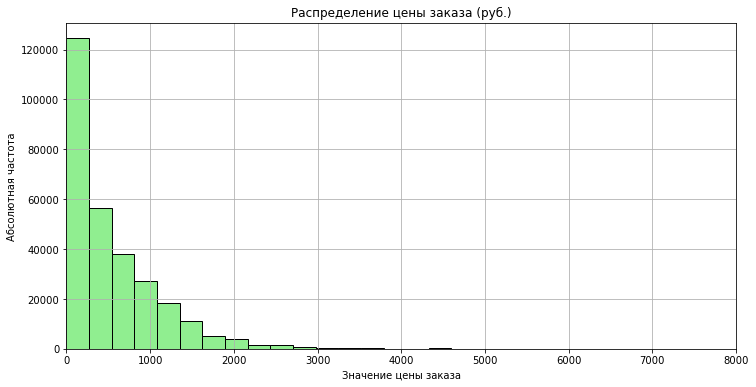

In [47]:
# Построим гистограмму

plt.figure(figsize = (12, 6))

df['revenue_rub'].plot(
        kind = 'hist',
        color = 'lightgreen',
        edgecolor = 'black',
        title = 'Распределение цены заказа (руб.)',
        bins = 300)

plt.xlabel('Значение цены заказа')
plt.xlim(left = 0, right=8000)  # Метод для ограничения по оси x

plt.ylabel('Абсолютная частота')

plt.grid()

plt.show()

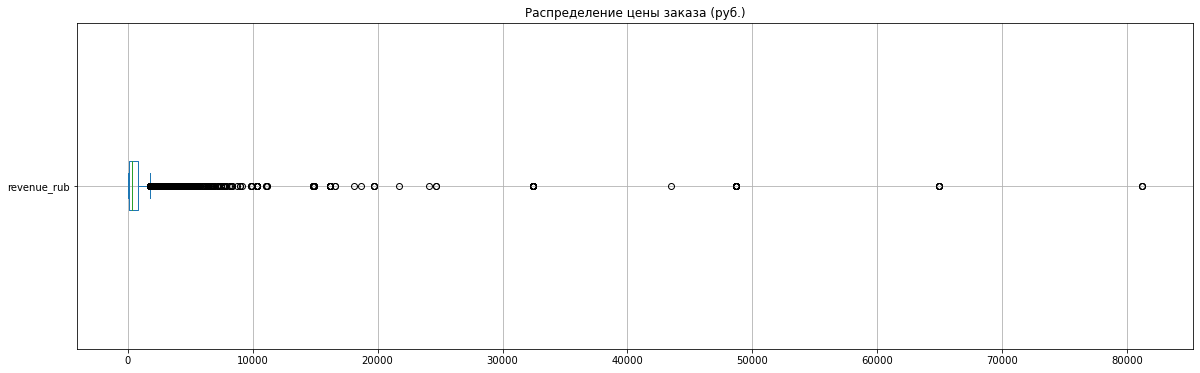

In [48]:
# Построим диаграмму размаха

plt.figure(figsize = (20, 6))

df['revenue_rub'].plot(
        kind = 'box',
        title = 'Распределение цены заказа (руб.)',
        vert = False)

plt.grid()

plt.show()

In [49]:
# Отфильтруем данный признак по 99-му процентилю

p99 = df['revenue_rub'].quantile(0.99)
df  = df[df['revenue_rub'] < p99]

In [50]:
# Количество строк

print(f"Количество строк после удаления лишних данных: {len(df)}")

Количество строк после удаления лишних данных: 287166


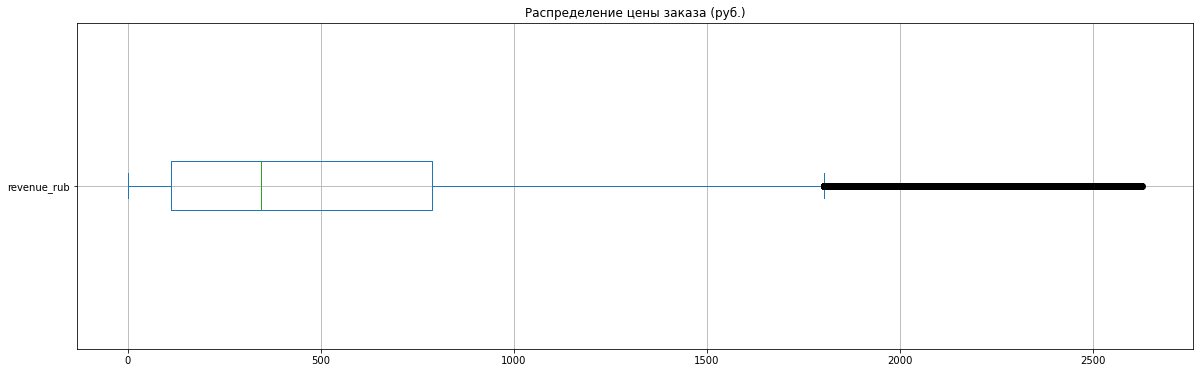

In [51]:
# Построим диаграмму размаха для исправленных данных

plt.figure(figsize = (20, 6))

df['revenue_rub'].plot(
        kind = 'box',
        title = 'Распределение цены заказа (руб.)',
        vert = False)

plt.grid()

plt.show()

In [52]:
df['revenue_rub'].describe()

count    287166.000000
mean        517.404175
std         509.316040
min           0.000000
25%         112.440002
50%         344.320007
75%         788.640015
max        2627.000000
Name: revenue_rub, dtype: float64

In [53]:
# Анализ столбца tickets_count

print(f"Признак tickets_count имеет тип данных {df['tickets_count'].dtype}.")

Признак tickets_count имеет тип данных int8.


In [54]:
# Узнаем основные статистические данные

df['tickets_count'].describe()

count    287166.000000
mean          2.741164
std           1.163430
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

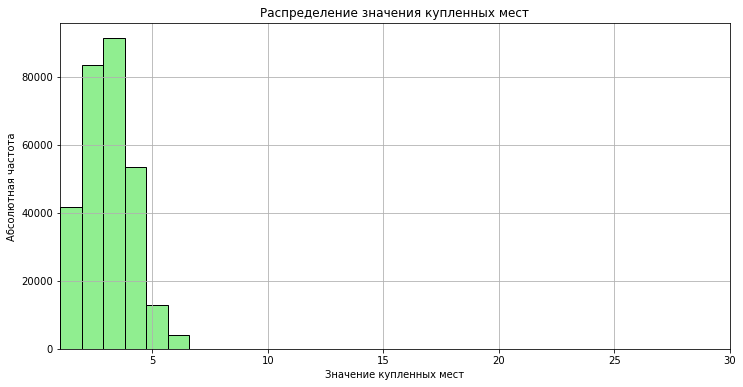

In [55]:
# Построим гистограмму

plt.figure(figsize = (12, 6))

df['tickets_count'].plot(
        kind = 'hist',
        color = 'lightgreen',
        edgecolor = 'black',
        title = 'Распределение значения купленных мест',
        bins = 60)

plt.xlabel('Значение купленных мест')
plt.xlim(left = 1, right=30)  # Метод для ограничения по оси x

plt.ylabel('Абсолютная частота')

plt.grid()

plt.show()

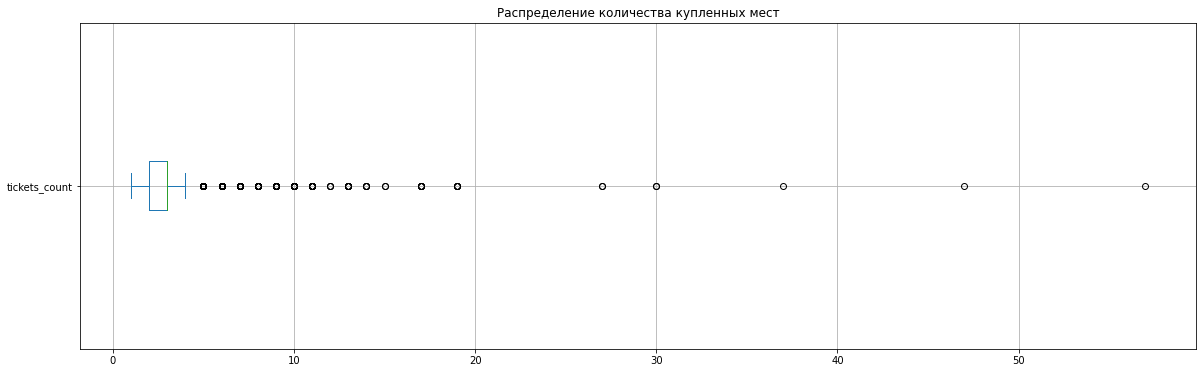

In [56]:
# Построим диаграмму размаха для исправленных данных

plt.figure(figsize = (20, 6))

df['tickets_count'].plot(
        kind = 'box',
        title = 'Распределение количества купленных мест',
        vert = False)

plt.grid()

plt.show()

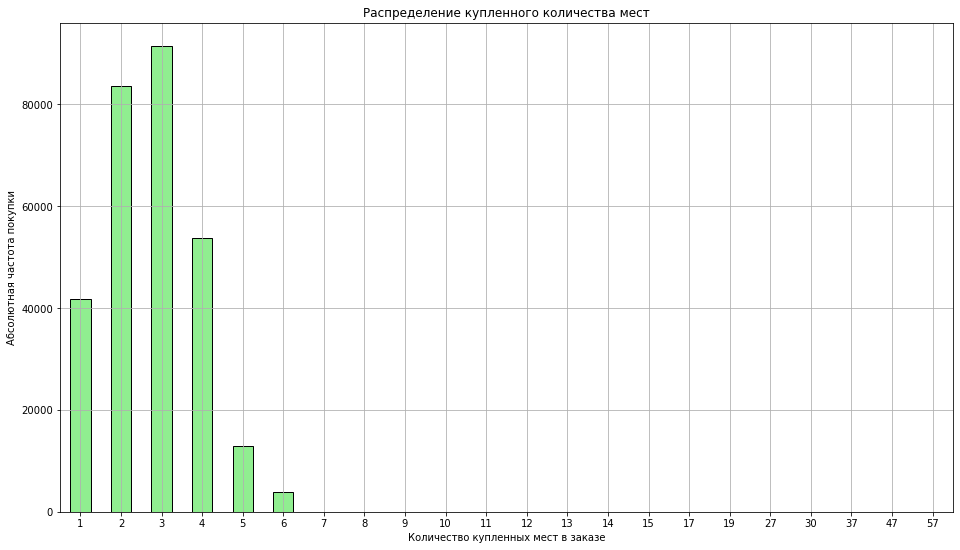

In [57]:
# Построим столбчатый график

plt.figure(figsize = (16, 9))

df.groupby('tickets_count')['tickets_count'].count().plot(
    kind = 'bar',
    title = 'Распределение купленного количества мест',
    color = 'lightgreen',
    edgecolor = 'black',
    rot = 0)

plt.xlabel('Количество купленных мест в заказе')
plt.ylabel('Абсолютная частота покупки')

plt.grid()

plt.show()

In [58]:
# Анализ столбца days_since_prev

print(f"Признак days_since_prev имеет тип данных {df['days_since_prev'].dtype}.")

Признак days_since_prev имеет тип данных int16.


In [59]:
# Узнаем основные статистические данные

df['days_since_prev'].describe()

count    287166.000000
mean          2.908318
std          10.981756
min          -1.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

In [60]:
# Узнаем какая часть данных имеет пропуски

print(f"Пропуски составляют {round(df['days_since_prev'].loc[df['days_since_prev'] == -1].shape[0] / df['days_since_prev'].shape[0], 4)} от всего датафрейма, т.е. {round(df['days_since_prev'].loc[df['days_since_prev'] == -1].shape[0] / df['days_since_prev'].shape[0]  * 100, 2)} %")

Пропуски составляют 0.0755 от всего датафрейма, т.е. 7.55 %


### Замечание
Это слишком большой объем данных, чтобы их удалять.

In [61]:
# При части анализа не будем учитывать отрицательные значения

df['days_since_prev'].loc[df['days_since_prev'] >= 0].describe()

count    265480.000000
mean          3.227573
std          11.362244
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

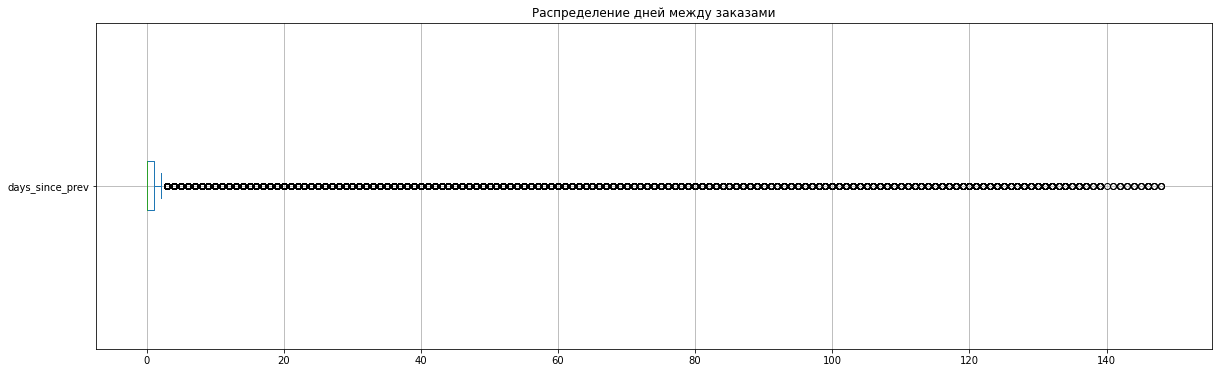

In [62]:
# Построим диаграмму размаха

plt.figure(figsize = (20, 6))

df['days_since_prev'].loc[df['days_since_prev'] >= 0].plot(
        kind = 'box',
        title = 'Распределение дней между заказами',
        vert = False)

plt.grid()

plt.show()

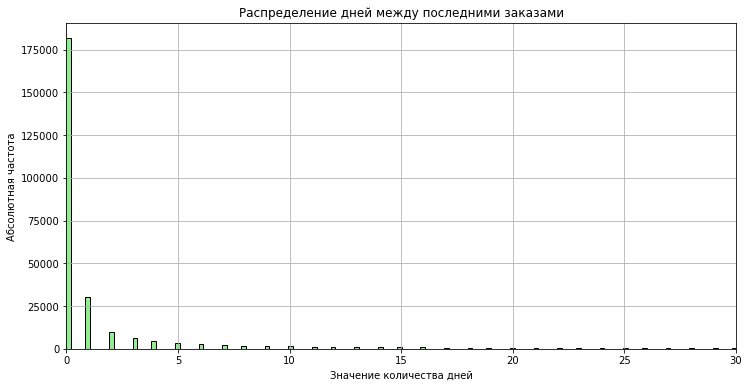

In [63]:
# Построим гистограмму

plt.figure(figsize = (12, 6))

df['days_since_prev'].loc[df['days_since_prev'] >= 0].plot(
        kind = 'hist',
        color = 'lightgreen',
        edgecolor = 'black',
        title = 'Распределение дней между последними заказами',
        bins = 700)

plt.xlabel('Значение количества дней')
plt.xlim(left = 0, right= 30)  # Метод для ограничения по оси x

plt.ylabel('Абсолютная частота')

plt.grid()

plt.show()

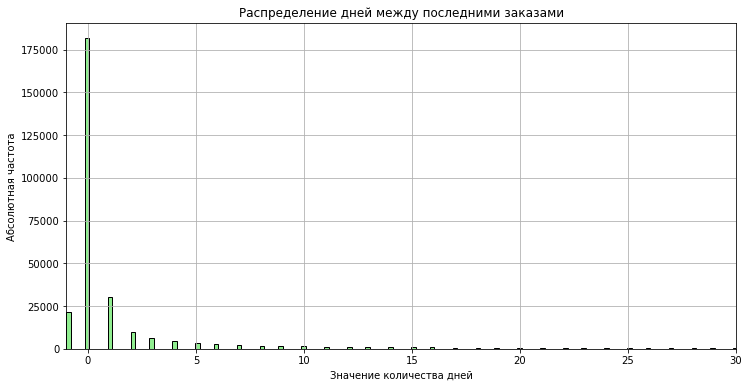

In [64]:
# Построим гистограмму с пропущенными данными

plt.figure(figsize = (12, 6))

df['days_since_prev'].plot(
        kind = 'hist',
        color = 'lightgreen',
        edgecolor = 'black',
        title = 'Распределение дней между последними заказами',
        bins = 700)

plt.xlabel('Значение количества дней')
plt.xlim(left = -1, right= 30)  # Метод для ограничения по оси x

plt.ylabel('Абсолютная частота')

plt.grid()

plt.show()

In [65]:
# Количество строк после предобработки

print(f"Итоговое количество строк после предобработки: {df.shape[0]}")
print(f"Начальное количество строк: {temp.shape[0]}")

print(f"Процент удаленных данных: {round((temp.shape[0] - df.shape[0]) / temp.shape[0] * 100, 4)}")
print(f"Количество удаленных строк: {temp.shape[0] - df.shape[0]}")

Итоговое количество строк после предобработки: 287166
Начальное количество строк: 290611
Процент удаленных данных: 1.1854
Количество удаленных строк: 3445


## Промежуточный вывод

#### Общий анализ

В рабочий датафрейм был добавлен новый признак `revenue_rub`, который содержит только значения в рублях. Для этого мы воспользовались вспомогательным датафреймом, который содержал как наш рабочий датафрейм, так и дополнительный датасет с курсом валют за эти числа.


Тип данных большинства признаков, которые имели тип данных `object`, был изменен на `category`. Пустые значения в столбце `days_since_prev` были заменены значением-индикатором `-1`, а также этот столбец был приведет к типу данных `int`. Во всех числовых признаках, где это было возможно, была уменьшена разрядность. Были найдены и отфильтрованы подозрительные значения в датафрейме, которые похожи на неявные дуюликаты. А также мы избавились от данных, которые имели отрицательные значения в столбцах `revenue_rub` и `revenue`.

#### Анализ числовых данных

Для ключевых численных признаков (`revenue_rub`, `tickets_count`) были представлены гистограммы и диаграммы размаха.

- Признак `revenue_rub`:
    * Были оценены основные статистики. Медиана находится левее чем среднее значение, что может указывать на правостороннюю асимметрию, которую мы видим на гистограмме. C помощью диаграммы размаха мы оценили данные на количество выбросов и избавились от них, отфильтровав по 99-му процентилю.
    * На отфильтрованных данных мы увидели, что правосторння асимметрия сохранилась, но в гораздо меньшей степени. Основные статистики изменились, стандартное отклонение данных уменьшилось в `2` раза.

- Признак `tickets_count`:
    * Были оценены основные статистики. Медиана находится правее, чем среднее значение, но стоит обратить внимание на то, что тип данных int и медиана не может принимать дробные значения, закон распределения будет дискретный. Из диаграммы размаха мы видим, что данные распределение имеет выбросы, а также медиана совпадает с третьим квартилем. Отлично распределение небольшого количества дискретных значений демонстрирует столбчатая диаграмма, на которой отлично видно, что чаще всего в заказе указывают три посадочных места.
    
- Признак `revenue` не анализировался так как является сырой версией признака `revenue_rub`.

- Признак `days_since_prev`:
    * Были оценены основные статистики. Медиана находится левее, чем среднее значение, так как есть существенные выбросы справа. На диаграмме размаха видим большую вариативность выбросов, так как не выбросами считаются чаще всего данные, где временной промежуток менее суток. Построив гистограмму похожую на столбчатую диаграмму, мы можем увидеть, что большее количество строк имеет значения `0` и `1`, т.е. заказы делаются чаще всего через небольшой промежуток времени. Однако доля единичных заказов тоже довольно существенна, но меньше чем доля, где диапазон времени `0` или `1` день.
    
#### Анализ фильтрации

По итогу `3445` строк были удалены, что составляет `1.1854 %` от исходных данных. Теперь данные предобработаны и сними можно работать.


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [66]:
# Отсортируем предобработанный датафрейм

df = df.sort_values(by = 'order_ts')

In [67]:
# Создадим новый пустой датафрейм профиля

df_profile = pd.DataFrame()

In [68]:
# Создадим датафрейм с первым заказаом для каждого пользователя

df_first_order = df.groupby('user_id').first().reset_index()

In [69]:
# Переименуем названия столбцов для первых заказов

df_first_order = df_first_order.rename(
    columns={
        'order_dt': 'first_order_dt',
        'device_type_canonical': 'first_device',
        'region_name': 'first_region',
        'service_name': 'first_service',
        'event_type_main': 'first_event_type'
    }
)

In [70]:
df_first_order

,user_id,first_device,order_id,first_order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_id_code,first_event_type,first_service,first_region,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.939941,4,-1,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,край_билетов,каменевский_регион,глиногорск,1521.939941
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.450012,2,-1,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,мой_билет,каменевский_регион,глиногорск,289.450012
2,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,-1,387271,2f638715-8844-466c-b43f-378a627c419f,другое,лови_билет!,североярская_область,озёрск,8.490000
3,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.830017,4,-1,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,край_билетов,каменевский_регион,глиногорск,917.830017
4,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.779999,1,-1,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,лучшие_билеты,поленовский_край,дальнозолотск,47.779999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21827,fff13b79bd47d7c,mobile,2668813,2024-07-16,2024-07-16 22:17:10,rub,297.040009,3,-1,536131,3ccd92b9-5450-40a1-a7a8-5075cf90cc6a,другое,мой_билет,каменевский_регион,глиногорск,297.040009
21828,fff32fc9ad0f9f6,desktop,2440931,2024-08-15,2024-08-15 14:36:28,rub,779.989990,3,-1,291439,9dbaefe5-56de-4b32-b991-7e9e4d04b702,стендап,билеты_без_проблем,каменевский_регион,глиногорск,779.989990
21829,fffcd3dde79eb2c,desktop,5114702,2024-06-20,2024-06-20 19:57:25,rub,367.559998,1,-1,529500,9303405c-c6df-4852-8768-73479f55dc25,концерты,билеты_без_проблем,каменевский_регион,глиногорск,367.559998
21830,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.530029,2,-1,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,билеты_без_проблем,широковская_область,ягодиновка,661.530029


In [71]:
# Создадим датафрейм с последним заказаом для каждого пользователя

df_last_order = df[['user_id', 'order_dt']].groupby('user_id').last().reset_index()

In [72]:
# Выведем данные из датафрейма с первыми заказами

df_last_order

,user_id,order_dt
0,0002849b70a3ce2,2024-08-20
1,0005ca5e93f2cf4,2024-10-06
2,000898990054619,2024-10-23
3,00096d1f542ab2b,2024-08-15
4,000a55a418c128c,2024-10-15
...,...,...
21827,fff13b79bd47d7c,2024-10-31
21828,fff32fc9ad0f9f6,2024-10-28
21829,fffcd3dde79eb2c,2024-10-30
21830,fffeeb3c120cf0b,2024-09-24


In [73]:
# Переименуем названия столбцов для последних

df_last_order = df_last_order.rename(
    columns={
        'order_dt': 'last_order_dt',
    }
)

In [74]:
# Выведем данные из датафрейма с последними заказами

df_last_order

,user_id,last_order_dt
0,0002849b70a3ce2,2024-08-20
1,0005ca5e93f2cf4,2024-10-06
2,000898990054619,2024-10-23
3,00096d1f542ab2b,2024-08-15
4,000a55a418c128c,2024-10-15
...,...,...
21827,fff13b79bd47d7c,2024-10-31
21828,fff32fc9ad0f9f6,2024-10-28
21829,fffcd3dde79eb2c,2024-10-30
21830,fffeeb3c120cf0b,2024-09-24


In [75]:
# Добавим всех уникальных пользователей в датафрейм

df_profile['user_id'] = df['user_id'].unique()

In [76]:
# Добавим в датафрейм профиля дату первого заказа

df_profile = df_profile.merge(df_first_order[['user_id', 'first_order_dt']], on = 'user_id', how = 'left')

In [77]:
# Добавим в датафрейм профиля дату последнего заказа

df_profile = df_profile.merge(df_last_order[['user_id', 'last_order_dt']], on = 'user_id', how = 'left')

In [78]:
# Данные с первой и последней датой

df_profile

,user_id,first_order_dt,last_order_dt
0,fd4d47438ebb946,2024-06-01,2024-10-31
1,57ef0a1905ac488,2024-06-01,2024-09-26
2,e73089d7d016cd8,2024-06-01,2024-10-31
3,18e9aead0a393e7,2024-06-01,2024-10-31
4,0e6fa925c5f346f,2024-06-01,2024-10-31
...,...,...,...
21827,f0dac51f739f59f,2024-10-31,2024-10-31
21828,176b51ad2feb561,2024-10-31,2024-10-31
21829,988e4859d820cb5,2024-10-31,2024-10-31
21830,e994c1637905fe5,2024-10-31,2024-10-31


In [79]:
# Добавим в датафрейм оставшиеся данные из для первых заказов

df_profile = df_profile.merge(df_first_order[['user_id', 'first_device', 'first_region', 'first_service', 'first_event_type']], on = 'user_id', how = 'left')

In [80]:
# Профиль пользователя со всеми данными из первого и последнего заказов

df_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type
0,fd4d47438ebb946,2024-06-01,2024-10-31,mobile,каменевский_регион,прачечная,театр
1,57ef0a1905ac488,2024-06-01,2024-09-26,mobile,лесодальний_край,билеты_в_руки,театр
2,e73089d7d016cd8,2024-06-01,2024-10-31,mobile,широковская_область,прачечная,театр
3,18e9aead0a393e7,2024-06-01,2024-10-31,mobile,каменевский_регион,облачко,концерты
4,0e6fa925c5f346f,2024-06-01,2024-10-31,mobile,речиновская_область,весь_в_билетах,концерты
...,...,...,...,...,...,...,...
21827,f0dac51f739f59f,2024-10-31,2024-10-31,mobile,солнечнореченская_область,облачко,концерты
21828,176b51ad2feb561,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты
21829,988e4859d820cb5,2024-10-31,2024-10-31,mobile,травяная_область,билеты_в_руки,театр
21830,e994c1637905fe5,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты


In [81]:
# Создадим датафрейм с агрегированными данными

df_total = df.groupby('user_id').agg(
    total_order_count = ('order_id', 'count'),
    avg_rub = ('revenue_rub', 'mean'),
    avg_tickets = ('tickets_count', 'mean')
).reset_index()

df_total

,user_id,total_order_count,avg_rub,avg_tickets
0,0002849b70a3ce2,1,1521.939941,4.000000
1,0005ca5e93f2cf4,2,774.010010,3.000000
2,000898990054619,3,767.213318,2.666667
3,00096d1f542ab2b,1,917.830017,4.000000
4,000a55a418c128c,2,61.309998,1.500000
...,...,...,...,...
21827,fff13b79bd47d7c,9,688.043335,2.555556
21828,fff32fc9ad0f9f6,2,850.994995,2.500000
21829,fffcd3dde79eb2c,33,557.908508,2.787879
21830,fffeeb3c120cf0b,1,661.530029,2.000000


In [82]:
# Присоединими агрегированные данные к профилю пользователя

df_profile = df_profile.merge(df_total, on = 'user_id', how = 'left')

df_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets
0,fd4d47438ebb946,2024-06-01,2024-10-31,mobile,каменевский_регион,прачечная,театр,1089,587.668945,2.694215
1,57ef0a1905ac488,2024-06-01,2024-09-26,mobile,лесодальний_край,билеты_в_руки,театр,4,797.937500,2.500000
2,e73089d7d016cd8,2024-06-01,2024-10-31,mobile,широковская_область,прачечная,театр,746,575.791565,2.746649
3,18e9aead0a393e7,2024-06-01,2024-10-31,mobile,каменевский_регион,облачко,концерты,4343,493.924713,2.789546
4,0e6fa925c5f346f,2024-06-01,2024-10-31,mobile,речиновская_область,весь_в_билетах,концерты,1493,557.637573,2.736772
...,...,...,...,...,...,...,...,...,...,...
21827,f0dac51f739f59f,2024-10-31,2024-10-31,mobile,солнечнореченская_область,облачко,концерты,1,380.299988,1.000000
21828,176b51ad2feb561,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,726.520020,3.000000
21829,988e4859d820cb5,2024-10-31,2024-10-31,mobile,травяная_область,билеты_в_руки,театр,1,19.610001,2.000000
21830,e994c1637905fe5,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,94.610001,1.000000


In [83]:
# Посчитаем для каждого заказа время от предыдущего по пользователю

df_diff_time = df[['user_id', 'order_ts']].copy().reset_index(drop = True)

df_diff_time['time_diff'] = df_diff_time.groupby('user_id')['order_ts'].diff()

df_diff_time

,user_id,order_ts,time_diff
0,fd4d47438ebb946,2024-06-01 00:00:42,NaT
1,fd4d47438ebb946,2024-06-01 00:01:30,0 days 00:00:48
2,57ef0a1905ac488,2024-06-01 00:01:58,NaT
3,fd4d47438ebb946,2024-06-01 00:03:13,0 days 00:01:43
4,e73089d7d016cd8,2024-06-01 00:03:34,NaT
...,...,...,...
287161,7eb4fc207ecc10f,2024-10-31 23:58:55,0 days 00:06:06
287162,3127060e4f02037,2024-10-31 23:58:56,0 days 00:14:56
287163,3127060e4f02037,2024-10-31 23:59:24,0 days 00:00:28
287164,3127060e4f02037,2024-10-31 23:59:51,0 days 00:00:27


In [84]:
# Считаем среднее для каждого пользователя

df_avg_time = df_diff_time.groupby('user_id')['time_diff'].mean().reset_index(name='avg_between_time')

In [85]:
# Выведем данные о среднем времени между заказами

df_avg_time

,user_id,avg_between_time
0,0002849b70a3ce2,NaT
1,0005ca5e93f2cf4,74 days 19:19:38
2,000898990054619,50 days 21:45:36
3,00096d1f542ab2b,NaT
4,000a55a418c128c,15 days 14:49:52
...,...,...
21827,fff13b79bd47d7c,13 days 08:31:50.250000
21828,fff32fc9ad0f9f6,74 days 09:04:10
21829,fffcd3dde79eb2c,4 days 02:48:08.062500
21830,fffeeb3c120cf0b,NaT


In [86]:
# Добавим среднее время между заказами в профиль пользователя

df_profile = df_profile.merge(df_avg_time, on = 'user_id', how = 'left')

df_profile['avg_between_time'] = df_profile['avg_between_time'].dt.round('1s')

In [87]:
# Выведем что получилось

df_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets,avg_between_time
0,fd4d47438ebb946,2024-06-01,2024-10-31,mobile,каменевский_регион,прачечная,театр,1089,587.668945,2.694215,0 days 03:22:27
1,57ef0a1905ac488,2024-06-01,2024-09-26,mobile,лесодальний_край,билеты_в_руки,театр,4,797.937500,2.500000,39 days 01:49:09
2,e73089d7d016cd8,2024-06-01,2024-10-31,mobile,широковская_область,прачечная,театр,746,575.791565,2.746649,0 days 04:55:36
3,18e9aead0a393e7,2024-06-01,2024-10-31,mobile,каменевский_регион,облачко,концерты,4343,493.924713,2.789546,0 days 00:50:44
4,0e6fa925c5f346f,2024-06-01,2024-10-31,mobile,речиновская_область,весь_в_билетах,концерты,1493,557.637573,2.736772,0 days 02:27:39
...,...,...,...,...,...,...,...,...,...,...,...
21827,f0dac51f739f59f,2024-10-31,2024-10-31,mobile,солнечнореченская_область,облачко,концерты,1,380.299988,1.000000,NaT
21828,176b51ad2feb561,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,726.520020,3.000000,NaT
21829,988e4859d820cb5,2024-10-31,2024-10-31,mobile,травяная_область,билеты_в_руки,театр,1,19.610001,2.000000,NaT
21830,e994c1637905fe5,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,94.610001,1.000000,NaT


In [88]:
# Сформируем бинарные признаки

df_profile['is_two'] = (df_profile['total_order_count'] >= 2)

df_profile['is_five'] = (df_profile['total_order_count'] >= 5)

In [89]:
df_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets,avg_between_time,is_two,is_five
0,fd4d47438ebb946,2024-06-01,2024-10-31,mobile,каменевский_регион,прачечная,театр,1089,587.668945,2.694215,0 days 03:22:27,True,True
1,57ef0a1905ac488,2024-06-01,2024-09-26,mobile,лесодальний_край,билеты_в_руки,театр,4,797.937500,2.500000,39 days 01:49:09,True,False
2,e73089d7d016cd8,2024-06-01,2024-10-31,mobile,широковская_область,прачечная,театр,746,575.791565,2.746649,0 days 04:55:36,True,True
3,18e9aead0a393e7,2024-06-01,2024-10-31,mobile,каменевский_регион,облачко,концерты,4343,493.924713,2.789546,0 days 00:50:44,True,True
4,0e6fa925c5f346f,2024-06-01,2024-10-31,mobile,речиновская_область,весь_в_билетах,концерты,1493,557.637573,2.736772,0 days 02:27:39,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21827,f0dac51f739f59f,2024-10-31,2024-10-31,mobile,солнечнореченская_область,облачко,концерты,1,380.299988,1.000000,NaT,False,False
21828,176b51ad2feb561,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,726.520020,3.000000,NaT,False,False
21829,988e4859d820cb5,2024-10-31,2024-10-31,mobile,травяная_область,билеты_в_руки,театр,1,19.610001,2.000000,NaT,False,False
21830,e994c1637905fe5,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,94.610001,1.000000,NaT,False,False


In [90]:
# Зафиксируем количество строк в датафрейме до предобработки

tmp_profile = df_profile.copy()
print(f"Количество строк в датафрейме: {tmp_profile.shape[0]}")

Количество строк в датафрейме: 21832


### Промежуточный вывод
Мы полностью подготовили датафрейм для профилей пользователей. Теперь у нас есть таблица, которая содержит основные данные для анализа поведения каждого пользователя, мы обобщили всю информацию из предобработанного датафрейма и теперь на шаг ближе к исследовательскому анализу данных, но перед этим следует проверить полученную таблицу.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [91]:
# Вычислим общее число пользователей в выборке

all_users = df_profile['user_id'].nunique()

print(f"Всего уникальных пользоватей: {all_users}")

Всего уникальных пользоватей: 21832


In [92]:
# Вычислим среднюю выручку с одного заказа

total_revenue = (df_profile['avg_rub'] * df_profile['total_order_count']).sum()

print(f"Общая взвешенная сумма всех заказов: {round(total_revenue, 2)}")

Общая взвешенная сумма всех заказов: 148581521.68


In [93]:
# Общее количество заказов

total_orders = df_profile['total_order_count'].sum()

print(f"Общее количество заказов: {total_orders}")

Общее количество заказов: 287166


In [94]:
# Вычислим среднюю выручку с одного заказа

overall_avg_revenue = total_revenue / total_orders

print(f"Средняя выручка с одного заказа: {round(overall_avg_revenue, 2)}")

Средняя выручка с одного заказа: 517.41


In [95]:
# Найдем долю пользователей совершивших 2 и более заказов

two_or_more = df_profile['is_two'].sum()

print(f"Доля пользователей, которые совершили два или более заказов от общего числа: {round(two_or_more / all_users, 3)}")

Доля пользователей, которые совершили два или более заказов от общего числа: 0.617


In [96]:
# Найдем долю пользователей совершивших 5 и более заказов

five_or_more = df_profile['is_five'].sum()

print(f"Доля пользователей, которые совершили пять или более заказов от общего числа: {round(five_or_more / all_users, 3)}")

Доля пользователей, которые совершили пять или более заказов от общего числа: 0.29


### Замечание
Переходим к анализу статистических показателей

In [97]:
# Статистические показатели по общему числу заказов

df_profile['total_order_count'].describe()

count    21832.000000
mean        13.153444
std        121.481195
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10156.000000
Name: total_order_count, dtype: float64

In [98]:
# Статистические показатели по среднему числу билетов в заказе

df_profile['avg_tickets'].describe()

count    21832.000000
mean         2.743852
std          0.913377
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: avg_tickets, dtype: float64

In [99]:
# Статистические показатели по среднему количеству дней между покупками

df_profile['avg_between_time'].dt.days.describe()

count    13472.000000
mean        15.504231
std         22.233514
min          0.000000
25%          1.000000
50%          8.000000
75%         20.000000
max        148.000000
Name: avg_between_time, dtype: float64

### Промежуточный вывод
Мы получили выборку с достаточным количеством данных для анализа. Среди статистических показателей были обнаружены аномальные значения.

- Так в признаке со средним числом билетов в заказе есть очень большие значения, из-за этого в данных очень большое стандартное отклонение. Также медиана сильно левее чем среднее значение. Избавимся от выбросов. Отфильтруем данные по процентилям и посмотрим что из этого выйдет.
- В признаке со средним количеством билетов выбросов меньше, а медиана и среднее значение очень близки, поэтому не будем избавляться от выбросов по этому признаку, так как данные выглядят не аномальными.

In [100]:
# Отфильтруем данные по 99-му процентилю

p99 = df_profile['total_order_count'].quantile(0.99)
df_profile_99 = df_profile.loc[df_profile['total_order_count'] < p99]

In [101]:
# Отфильтруем данные по 95-му процентилю

p95 = df_profile['total_order_count'].quantile(0.95)
df_profile_95 = df_profile.loc[df_profile['total_order_count'] < p95]

In [102]:
# Количество строк в датафрейме после предобработки по 99-му процентилю

print(f"Количество строк в датафрейме: {df_profile_99.shape[0]}\n")
print(f"Разность с исходным датафреймом: {tmp_profile.shape[0] - df_profile_99.shape[0]}\n")
print(f"Часть данных, которая была удалена: {round((tmp_profile.shape[0] - df_profile_99.shape[0]) / tmp_profile.shape[0], 3)}")

Количество строк в датафрейме: 21612

Разность с исходным датафреймом: 220

Часть данных, которая была удалена: 0.01


In [103]:
# Количество строк в датафрейме после предобработки по 95-му процентилю

print(f"Количество строк в датафрейме: {df_profile_95.shape[0]}\n")
print(f"Разность с исходным датафреймом: {tmp_profile.shape[0] - df_profile_95.shape[0]}\n")
print(f"Часть данных, которая была удалена: {round((tmp_profile.shape[0] - df_profile_95.shape[0]) / tmp_profile.shape[0], 3)}")

Количество строк в датафрейме: 20712

Разность с исходным датафреймом: 1120

Часть данных, которая была удалена: 0.051


In [104]:
# Статистические показатели для отфильтрованных данных по общему числу заказов по 99-му процентилю

df_profile_99['total_order_count'].describe()

count    21612.000000
mean         6.465575
std         14.157089
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        151.000000
Name: total_order_count, dtype: float64

In [105]:
# Статистические показатели для отфильтрованных данных по общему числу заказов по 95-му процентилю

df_profile_95['total_order_count'].describe()

count    20712.000000
mean         4.009898
std          5.013877
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         30.000000
Name: total_order_count, dtype: float64

### Промежуточный вывод
Опираясь на признак `total_order_count` данные по 95-му процентилю демонстрируют более реалистичные значения. Можно предположить ряд гипотез откуда берутся столь высокие значения данных, например какая-то фирма или компания-посредник выкупает билеты, это вполне реалистичный сценарий, но такие данные нам никак не помогут проанализировать поведение конкретного пользователя. 

In [106]:
# Присвоим датафрейму полученные данные

df_profile = df_profile_95.copy().reset_index(drop = True)
df_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets,avg_between_time,is_two,is_five
0,57ef0a1905ac488,2024-06-01,2024-09-26,mobile,лесодальний_край,билеты_в_руки,театр,4,797.937500,2.5,39 days 01:49:09,True,False
1,8b9ff6a430865fb,2024-06-01,2024-10-12,desktop,малиновоярский_округ,билеты_без_проблем,концерты,9,783.963318,2.0,16 days 17:29:24,True,True
2,520a8c0f376287b,2024-06-01,2024-06-01,mobile,луговая_область,билеты_без_проблем,другое,1,71.570000,1.0,NaT,False,False
3,a044b39568cedcb,2024-06-01,2024-10-25,desktop,каменевский_регион,билеты_без_проблем,концерты,2,1062.635010,2.5,146 days 15:06:11,True,False
4,c9f1f9e2967b769,2024-06-01,2024-06-01,mobile,берёзовская_область,билеты_без_проблем,другое,1,26.219999,2.0,NaT,False,False


In [107]:
# Статистические показатели по среднему числу билетов в заказе по 95-му процентилю

df_profile['avg_tickets'].describe()

count    20712.000000
mean         2.744462
std          0.935373
min          1.000000
25%          2.000000
50%          2.750000
75%          3.166667
max         11.000000
Name: avg_tickets, dtype: float64

In [108]:
# Статистические показатели по среднему количеству дней между покупками по 95-му процентилю

df_profile['avg_between_time'].dt.days.describe()

count    12352.000000
mean        16.749676
std         22.810956
min          0.000000
25%          0.000000
50%          9.000000
75%         22.000000
max        148.000000
Name: avg_between_time, dtype: float64

### Промежуточный вывод

Для исследовательского анализа данных было необходимо собрать агрегированные данные по каждому пользователю, мы посторили профили пользователей в виде датафрейма, где указана основная информация по каждому пользователю. С помощью данных, которые были получены, можно надежно анализировать поведение пользователей и строить модели. Данные были дополнительно отфильтрованы, т.к. нас интересует поведение пользователей и их возврат на платформу, а данные, которые явно имели другую природу портили качество датафрейма.


Теперь статистические показатели выглядят вполне реалистично, в критически важных признаках медиана и среднее значение близки, что указывает на нормальное распределение данных.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [109]:
# Группировка пользователей по типу первого мероприятия(абсолютная частота)
users_per_event = df_profile.groupby('first_event_type')['user_id'].count().sort_values(ascending = False).reset_index(name = 'count_users')
users_per_event

,first_event_type,count_users
0,концерты,9167
1,другое,5153
2,театр,4065
3,стендап,1069
4,спорт,763
5,выставки,401
6,ёлки,94


In [110]:
# Группировка пользователей по типу первого мероприятия(относительная частота)
users_per_event_relative = df_profile['first_event_type'].value_counts(normalize = True)
users_per_event_relative

концерты    0.442594
другое      0.248793
театр       0.196263
стендап     0.051613
спорт       0.036839
выставки    0.019361
ёлки        0.004538
Name: first_event_type, dtype: float64

In [111]:
# Группировка пользователей по типу первого устройства(абсолютная частота)
users_per_device = df_profile.groupby('first_device')['user_id'].count().sort_values(ascending = False).reset_index(name = 'count_users')
users_per_device



,first_device,count_users
0,mobile,17181
1,desktop,3531


In [112]:
# Группировка пользователей по типу первого устройства(относительная частота)
users_per_device_relative = df_profile['first_device'].value_counts(normalize = True)
users_per_device_relative

mobile     0.829519
desktop    0.170481
Name: first_device, dtype: float64

In [113]:
# Группировка пользователей по типу первого региона(абсолютная частота)
users_per_region = df_profile.groupby('first_region')['user_id'].count().sort_values(ascending = False).reset_index(name = 'count_users')
users_per_region

,first_region,count_users
0,каменевский_регион,6775
1,североярская_область,3597
2,широковская_область,1181
3,озернинский_край,659
4,малиновоярский_округ,516
...,...,...
76,залесский_край,2
77,верхозёрский_край,1
78,светолесский_край,1
79,сосноводолинская_область,1


In [114]:
# Группировка пользователей по типу первого региона(относительная частота)
users_per_region_relative = df_profile['first_region'].value_counts(normalize = True)
users_per_region_relative

каменевский_регион          0.327105
североярская_область        0.173667
широковская_область         0.057020
озернинский_край            0.031817
малиновоярский_округ        0.024913
                              ...   
залесский_край              0.000097
верхозёрский_край           0.000048
светолесский_край           0.000048
сосноводолинская_область    0.000048
яснопольский_округ          0.000048
Name: first_region, Length: 81, dtype: float64

In [115]:
# Группировка пользователей по типу первого билетного оператора(абсолютная частота)
users_per_service = df_profile.groupby('first_service')['user_id'].count().sort_values(ascending = False).reset_index(name = 'count_users')
users_per_service

,first_service,count_users
0,билеты_без_проблем,4949
1,мой_билет,2840
2,лови_билет!,2703
3,билеты_в_руки,2420
4,облачко,2107
5,весь_в_билетах,1232
6,лучшие_билеты,1130
7,прачечная,549
8,край_билетов,438
9,дом_культуры,339


In [116]:
# Группировка пользователей по типу первого билетного оператора(относительная частота)
users_per_service_relative = df_profile['first_service'].value_counts(normalize = True)
users_per_service_relative

билеты_без_проблем        0.238944
мой_билет                 0.137119
лови_билет!               0.130504
билеты_в_руки             0.116840
облачко                   0.101728
весь_в_билетах            0.059482
лучшие_билеты             0.054558
прачечная                 0.026506
край_билетов              0.021147
дом_культуры              0.016367
яблоко                    0.014871
тебе_билет!               0.014340
городской_дом_культуры    0.010091
мир_касс                  0.009608
за_билетом!               0.009463
быстробилет               0.007677
show_ticket               0.007484
выступления.ру            0.004442
восьмёрка                 0.003959
быстрый_кассир            0.002655
crazy_ticket!             0.002028
росбилет                  0.001931
радио_ticket              0.001738
реестр                    0.001304
телебилет                 0.001304
цвет_и_билет              0.001014
шоу_начинается!           0.000869
карандашру                0.000676
кино_билет          

### Промежуточный вывод
Пользователи распределены неравномерно между категориями в признаках. Выделяются в каждом признаке явные точки входа:
- Для `first_event_type`: `концерты`
- Для `first_device`: `mobile`
- Для `first_region`: `каменевский_регион`
- Для `first_service`: `билеты_без_проблем`


Мы можем увидеть, что в каждом признаке есть явный лидер по категориям.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


### Замечание
Проанализируем признак `first_event_type`.

In [117]:
# Количество пользователей, которые совершили два и более заказов по категории

users_per_event_is_two = df_profile.groupby('first_event_type')['is_two'].sum().sort_values(ascending = False).reset_index(name = 'count_is_two')

users_per_event_is_two

,first_event_type,count_is_two
0,концерты,5518
1,другое,2969
2,театр,2513
3,стендап,635
4,спорт,412
5,выставки,253
6,ёлки,52


In [118]:
# Объединяем датафреймы и вычисляем отношение
df_events = users_per_event_is_two.merge(users_per_event, on = 'first_event_type', how = 'left')
df_events['two_to_all'] = round(df_events['count_is_two'] / df_events['count_users'], 4)

df_events

,first_event_type,count_is_two,count_users,two_to_all
0,концерты,5518,9167,0.6019
1,другое,2969,5153,0.5762
2,театр,2513,4065,0.6182
3,стендап,635,1069,0.5940
4,спорт,412,763,0.5400
5,выставки,253,401,0.6309
6,ёлки,52,94,0.5532


In [119]:
# Количество пользователей, которые совершили два и более заказов по устройству

users_per_device_is_two = df_profile.groupby('first_device')['is_two'].sum().sort_values(ascending = False).reset_index(name = 'count_is_two')

users_per_device_is_two

,first_device,count_is_two
0,mobile,10162
1,desktop,2190


In [120]:
# Объединяем датафреймы и вычисляем отношение
df_devices = users_per_device_is_two.merge(users_per_device, on = 'first_device', how = 'left')
df_devices['two_to_all'] = round(df_devices['count_is_two'] / df_devices['count_users'], 4)

df_devices

,first_device,count_is_two,count_users,two_to_all
0,mobile,10162,17181,0.5915
1,desktop,2190,3531,0.6202


In [121]:
# Количество пользователей, которые совершили два и более заказов по региону

users_per_region_is_two = df_profile.groupby('first_region')['is_two'].sum().sort_values(ascending = False).reset_index(name = 'count_is_two')

users_per_region_is_two

,first_region,count_is_two
0,каменевский_регион,4110
1,североярская_область,2234
2,широковская_область,746
3,озернинский_край,357
4,шанырский_регион,298
...,...,...
76,залесский_край,1
77,светолесский_край,0
78,сосноводолинская_область,0
79,островогорский_округ,0


In [122]:
# Объединяем датафреймы и вычисляем отношение
df_regions = users_per_region_is_two.merge(users_per_region, on = 'first_region', how = 'left')
df_regions['two_to_all'] = round(df_regions['count_is_two'] / df_regions['count_users'], 4)

df_regions

,first_region,count_is_two,count_users,two_to_all
0,каменевский_регион,4110,6775,0.6066
1,североярская_область,2234,3597,0.6211
2,широковская_область,746,1181,0.6317
3,озернинский_край,357,659,0.5417
4,шанырский_регион,298,462,0.6450
...,...,...,...,...
76,залесский_край,1,2,0.5000
77,светолесский_край,0,1,0.0000
78,сосноводолинская_область,0,1,0.0000
79,островогорский_округ,0,4,0.0000


In [123]:
# Количество пользователей, которые совершили два и более заказов по сервису

users_per_service_is_two = df_profile.groupby('first_service')['is_two'].sum().sort_values(ascending = False).reset_index(name = 'count_is_two')

users_per_service_is_two

,first_service,count_is_two
0,билеты_без_проблем,2899
1,мой_билет,1681
2,лови_билет!,1605
3,билеты_в_руки,1468
4,облачко,1263
5,весь_в_билетах,755
6,лучшие_билеты,673
7,прачечная,331
8,край_билетов,280
9,дом_культуры,213


In [124]:
# Объединяем датафреймы и вычисляем отношение
df_services = users_per_service_is_two.merge(users_per_service, on = 'first_service', how = 'left')
df_services['two_to_all'] = round(df_services['count_is_two'] / df_services['count_users'], 4)

df_services

,first_service,count_is_two,count_users,two_to_all
0,билеты_без_проблем,2899,4949,0.5858
1,мой_билет,1681,2840,0.5919
2,лови_билет!,1605,2703,0.5938
3,билеты_в_руки,1468,2420,0.6066
4,облачко,1263,2107,0.5994
5,весь_в_билетах,755,1232,0.6128
6,лучшие_билеты,673,1130,0.5956
7,прачечная,331,549,0.6029
8,край_билетов,280,438,0.6393
9,дом_культуры,213,339,0.6283


### Замечание
Для визуализации категорий можно использоватль линейные или столбчатые диаграммы. Покажем результаты на линейчатых диаграммах.

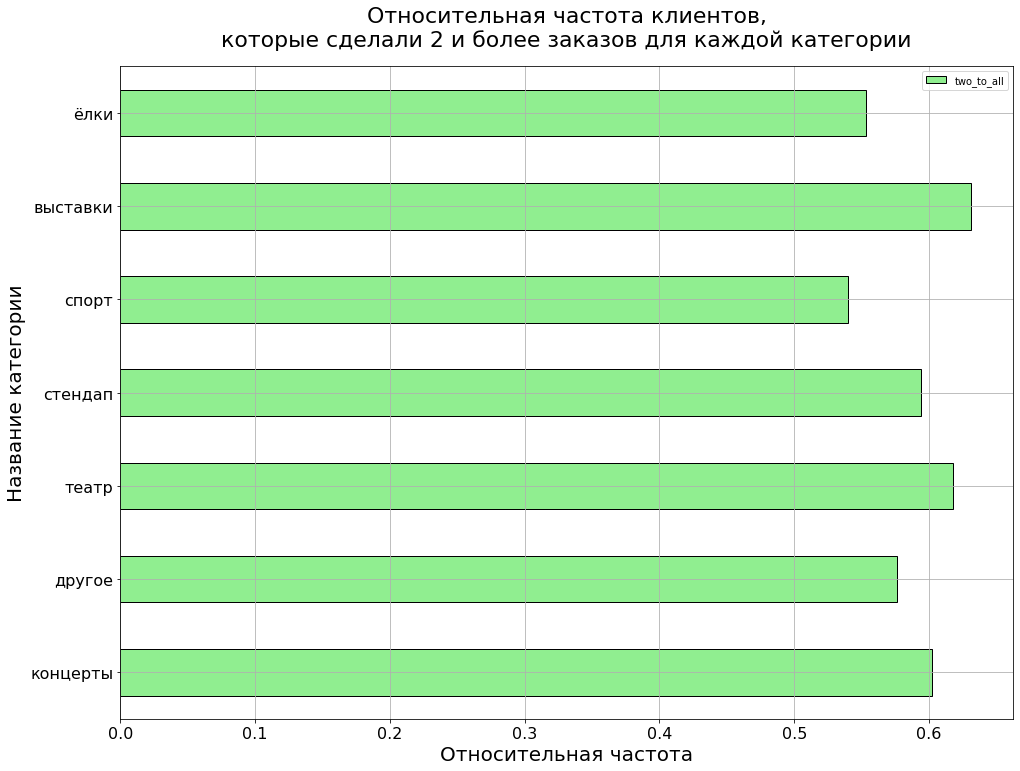

In [125]:
# Визуализируем распределение

df_events[['first_event_type', 'two_to_all']].plot(
    kind = 'barh',
    x = 'first_event_type',
    y = 'two_to_all',
    figsize = (16, 12),
    color = 'lightgreen',
    edgecolor = 'black')

plt.grid()
plt.xlabel('Относительная частота', fontsize = 20)
plt.ylabel('Название категории', fontsize = 20)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.title('Относительная частота клиентов,\nкоторые сделали 2 и более заказов для каждой категории', 
          fontsize=22,  # ← размер шрифта
          pad=20)       # ← отступ от графика


plt.show()

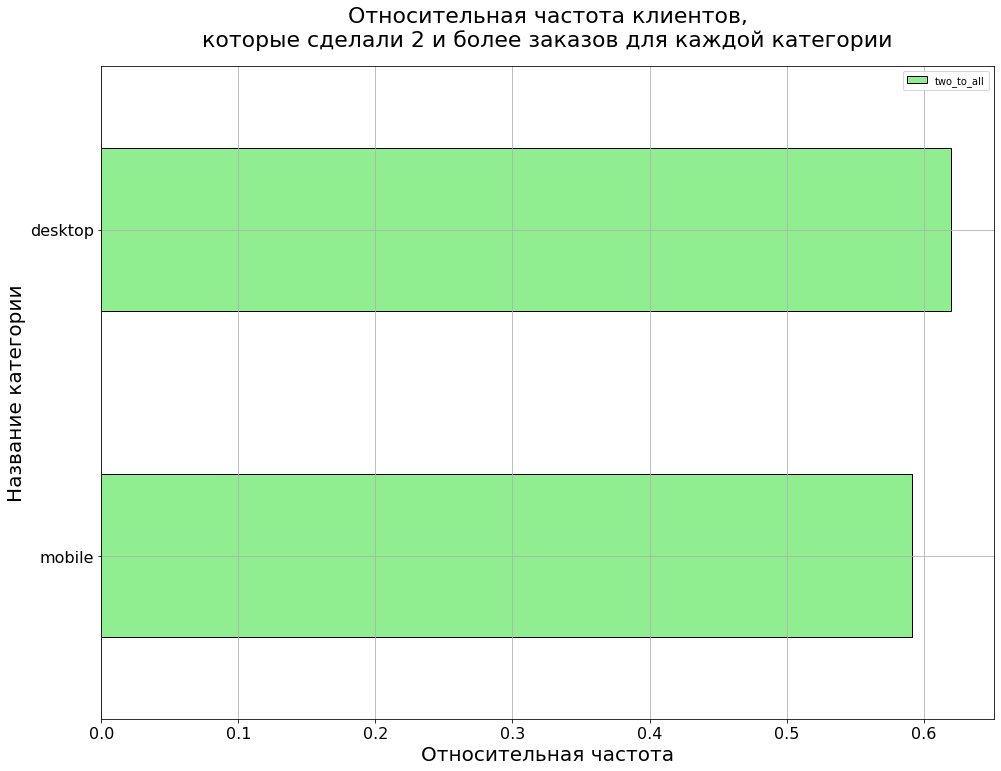

In [126]:
# Визуализируем распределение

df_devices[['first_device', 'two_to_all']].plot(
    kind = 'barh',
    x = 'first_device',
    y = 'two_to_all',
    figsize = (16, 12),
    color = 'lightgreen',
    edgecolor = 'black')

plt.grid()
plt.xlabel('Относительная частота', fontsize = 20)
plt.ylabel('Название категории', fontsize = 20)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.title('Относительная частота клиентов,\nкоторые сделали 2 и более заказов для каждой категории', 
          fontsize=22,  # ← размер шрифта
          pad=20)       # ← отступ от графика


plt.show()

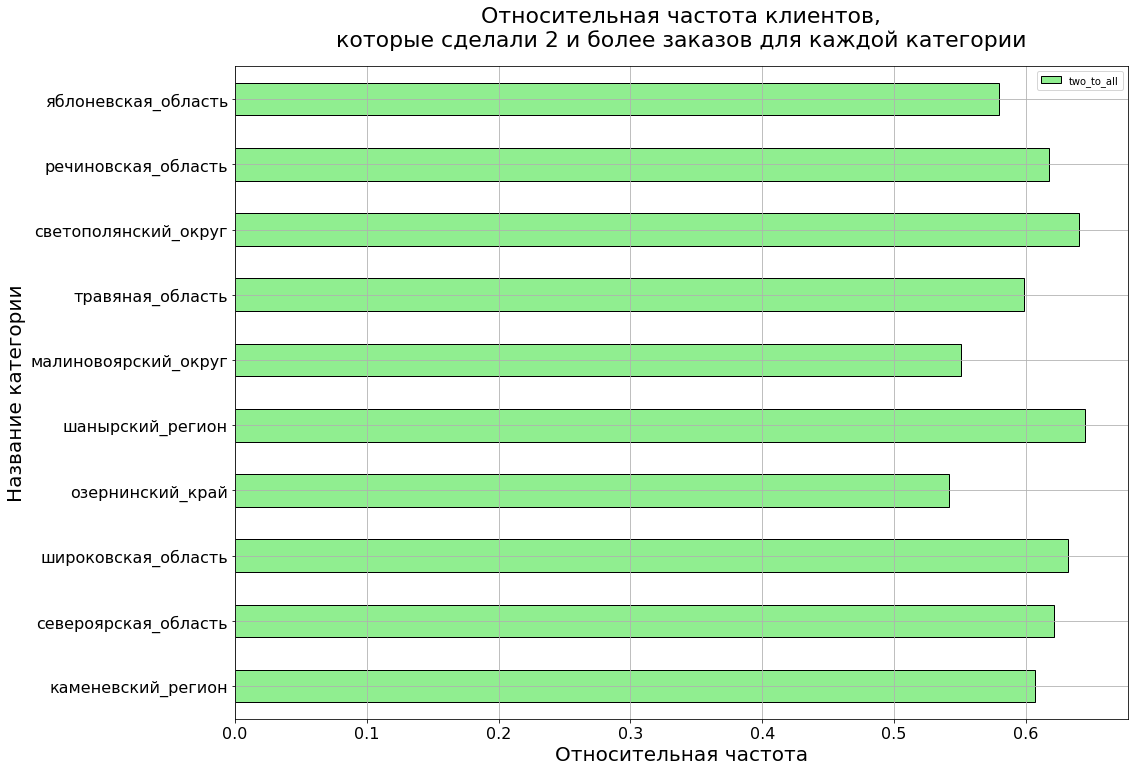

In [127]:
# Визуализируем распределение

df_regions.head(10)[['first_region', 'two_to_all']].head(10).plot(
    kind = 'barh',
    x = 'first_region',
    y = 'two_to_all',
    figsize = (16, 12),
    color = 'lightgreen',
    edgecolor = 'black')

plt.grid()
plt.xlabel('Относительная частота', fontsize = 20)
plt.ylabel('Название категории', fontsize = 20)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.title('Относительная частота клиентов,\nкоторые сделали 2 и более заказов для каждой категории', 
          fontsize=22,  # ← размер шрифта
          pad=20)       # ← отступ от графика


plt.show()

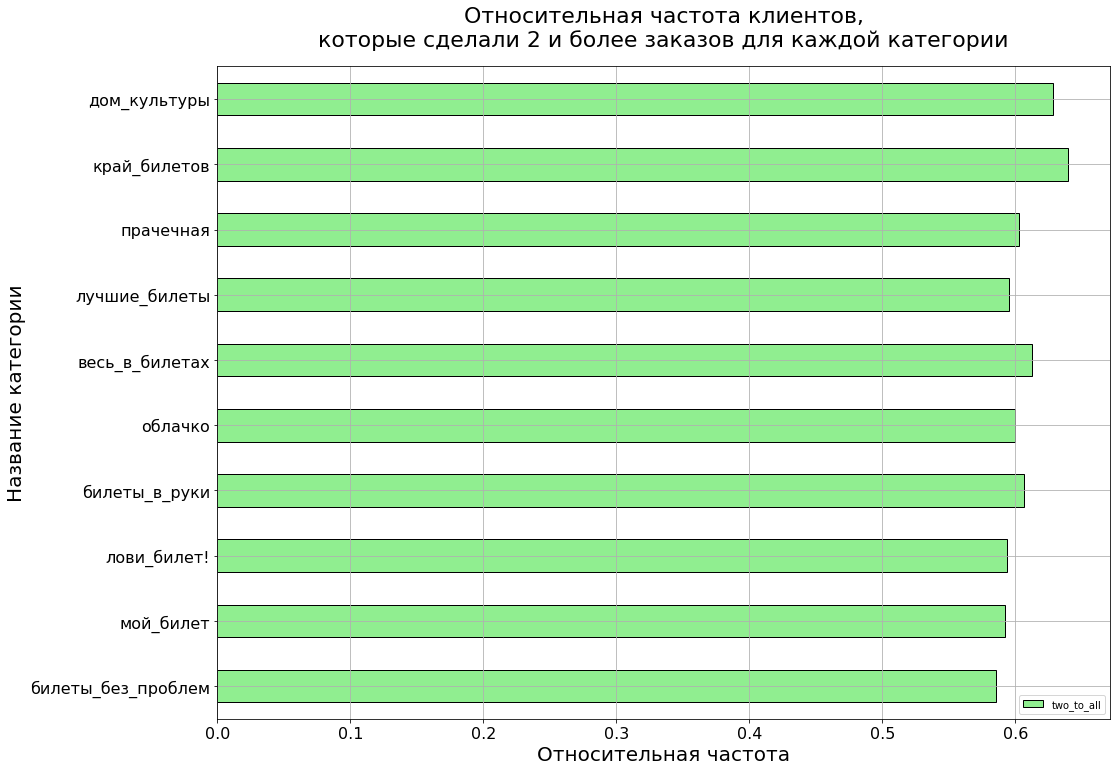

In [128]:
# Визуализируем распределение

df_services.head(10)[['first_service', 'two_to_all']].plot(
    kind = 'barh',
    x = 'first_service',
    y = 'two_to_all',
    figsize = (16, 12),
    color = 'lightgreen',
    edgecolor = 'black')

plt.grid()
plt.xlabel('Относительная частота', fontsize = 20)
plt.ylabel('Название категории', fontsize = 20)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.title('Относительная частота клиентов,\nкоторые сделали 2 и более заказов для каждой категории', 
          fontsize=22,  # ← размер шрифта
          pad=20)       # ← отступ от графика


plt.show()

### Замечание
Дополнительные вычисления, чтобы ответить на вопросы. Будем рассматривать только сегменты, где больше десяти пользователей.

In [129]:
# Топ 3 по повторным заказам среди событий

df_events.loc[df_events['count_users'] > 10][['first_event_type', 'two_to_all']].sort_values(ascending = False, by = 'two_to_all').head(3).reset_index(drop = True)

,first_event_type,two_to_all
0,выставки,0.6309
1,театр,0.6182
2,концерты,0.6019


In [130]:
# Повторные заказы среди девайсов

df_devices.loc[df_devices['count_users'] > 10][['first_device', 'two_to_all']].sort_values(ascending = False, by = 'two_to_all').reset_index(drop = True)

,first_device,two_to_all
0,desktop,0.6202
1,mobile,0.5915


In [131]:
# Топ 3 по повторным заказам среди регионов

df_regions.loc[df_regions['count_users'] > 10][['first_region', 'two_to_all']].sort_values(ascending = False, by = 'two_to_all').head(3).reset_index(drop = True)

,first_region,two_to_all
0,озернопольская_область,0.8889
1,радужнопольский_край,0.7619
2,лесостепной_край,0.6909


In [132]:
# Топ 3 по повторным заказам среди сервисов

df_services.loc[df_services['count_users'] > 10][['first_service', 'two_to_all']].sort_values(ascending = False, by = 'two_to_all').head(3).reset_index(drop = True)

,first_service,two_to_all
0,быстрый_кассир,0.8364
1,реестр,0.7778
2,восьмёрка,0.6707


### Замечание
Также найдем средний показатель возврата по выборке категорий.

In [133]:
# Ищем среднее значение

print(f"Среднее отношение клиентов, которые вернулись на платформу ко всем от типа мероприятия: {round(df_events['two_to_all'].mean(), 3)}")

Среднее отношение клиентов, которые вернулись на платформу ко всем от типа мероприятия: 0.588


In [134]:
# Ищем среднее значение

print(f"Среднее отношение клиентов, которые вернулись на платформу ко всем от типа устройства: {round(df_devices['two_to_all'].mean(), 3)}")

Среднее отношение клиентов, которые вернулись на платформу ко всем от типа устройства: 0.606


In [135]:
# Ищем среднее значение

print(f"Среднее отношение клиентов, которые вернулись на платформу ко всем от типа региона: {round(df_regions['two_to_all'].mean(), 3)}")

Среднее отношение клиентов, которые вернулись на платформу ко всем от типа региона: 0.533


In [136]:
# Ищем среднее значение

print(f"Среднее отношение клиентов, которые вернулись на платформу ко всем от типа сервиса: {round(df_services['two_to_all'].mean(), 3)}")

Среднее отношение клиентов, которые вернулись на платформу ко всем от типа сервиса: 0.597


### Промежуточный вывод
   Сегменты, которые чаще всего возвращаются на Яндекс Афишу. Рассмотрим топ 3 по каждому признаку:
   - `первые события`
       * выставки (0.6309)
       * театр (0.6182)
       * концерты(0.6019)
   - `девайсы` (всего 2 типа)
       * desktop(0.6202)
       * mobile(0.5915)
   - `регионы`
       * озернопольская_область (0.8889)
       * радужнопольский_край (0.7619)
       * лесостепной_край (0.6909)
   - `сервисы`
       * быстрый_кассир	(0.8364)
       * реестр	(0.7778)
       * восьмёрка (0.6707)
       
Cоответсвенно, выше мы видим какие из сегментов показывают самые высокие показатели по возврату клиентов на платформу.


Все топ 3 события из выборок являются хорошими точками входа, т.к. относительное количество клиентов, которые возвращаются выше чем в среднем по выборке. Что касается девайсов, то пользователи, которые использовали станционарный компьютер в среднем чаще возвращаются на платформу, это может быть связано с комфортом и удобством работы с сайтом на устройстве.

Успешных точек входа можно привести больше чем топ 3.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

### Гипотеза 1
Из анализа, который мы провели выше, действительно видно, что тип мероприятия влияет на вероятность возврата на Яндекс Афишу.

Однако если рассматривать спортивные мероприятия, то можно заметить, что:
- это не популярный тип событий на Яндекс Афише
- этот тип событий имеет один из худший показателей по повторным обращениям клиентов.

Если же посмотрим на концерты, то это один из лидеров по количеству клиентов, а также имеет показатель по возвращению клиентов на `6%` выше, чем спортивные мероприятия.

### Гипотеза 2
Стоит понимать, что регионы, где заказов очень мало анализировать некорректно, т.к. выборка слишком мала. Будем рассматривать регионы, где пользователей больше 10-ти.

In [137]:
# Выведем регионы, где мало пользователей

df_regions.loc[df_regions['count_users'] > 10].sort_values(by = 'count_users').head(10)

,first_region,count_is_two,count_users,two_to_all
64,тихореченская_область,7,12,0.5833
66,радужногорская_область,5,14,0.3571
63,вишнёвский_край,8,14,0.5714
62,лесоярская_область,10,16,0.6250
61,белоярская_область,10,17,0.5882
54,радужнопольский_край,16,21,0.7619
58,берестовский_округ,14,22,0.6364
52,горноземский_регион,17,26,0.6538
60,серебряноярский_округ,12,27,0.4444
43,озернопольская_область,24,27,0.8889


In [138]:
# Выведем регионы, где много пользователей

df_regions.sort_values(by = 'count_users', ascending = False).head(10)

,first_region,count_is_two,count_users,two_to_all
0,каменевский_регион,4110,6775,0.6066
1,североярская_область,2234,3597,0.6211
2,широковская_область,746,1181,0.6317
3,озернинский_край,357,659,0.5417
5,малиновоярский_округ,284,516,0.5504
6,травяная_область,280,468,0.5983
4,шанырский_регион,298,462,0.6450
7,светополянский_округ,279,436,0.6399
8,речиновская_область,260,421,0.6176
9,яблоневская_область,230,397,0.5793


In [139]:
# Посчитаем средние

avg_min_region = df_regions.loc[df_regions['count_users'] > 10].sort_values(by = 'count_users').head(10)['two_to_all'].mean()
print(f"Средний показатель возврата в регионах, где мало пользователей: {round(avg_min_region, 4)}")

avg_max_region = df_regions.sort_values(by = 'count_users', ascending = False).head(10)['two_to_all'].mean()
print(f"Средний показатель возврата в регионах, где много пользователей: {round(avg_max_region, 4)}")

Средний показатель возврата в регионах, где мало пользователей: 0.611
Средний показатель возврата в регионах, где много пользователей: 0.6032


### Замечание
Видим, что показатель для регионов, где много пользователей на процент меньше. Данный результат не может подтвердить нашу гипотезу. После проведенного анализа мы можем сделать вывод, что численность региона не влияет показатели повторных заказов у клиентов. В целом анализ регионов, где мало пользователей не очень корректен, так как выборка мала, чтобы сделать объективные выводы. Некоторые регионы с малым количеством людей могут показывать очень низкие или очень высокие показатели.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


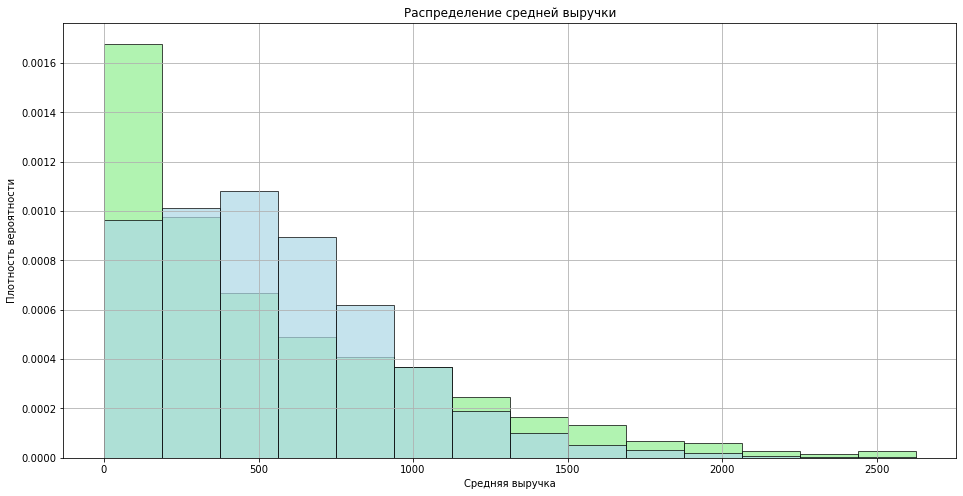

In [140]:
# Визуализируем распределение пользователей

plt.figure(figsize = (16, 8))

# Правило Стерджеса для оптимального количества бинов
k_f = round(1 + (3.322 * math.log10(df_profile.loc[df_profile['is_two'] == False]['avg_rub'].size)))
k_t = round(1 + (3.322 * math.log10(df_profile.loc[df_profile['is_two'] == True]['avg_rub'].size)))
k = round((k_f + k_t) / 2)

df_profile.loc[df_profile['is_two'] == False]['avg_rub'].plot(
    kind = 'hist',
    bins = k,
    color = 'lightgreen',
    edgecolor = 'black',
    title = 'Распределение средней выручки',
    alpha = 0.7,
    density = True,
    label = 'is_two = True')

df_profile.loc[df_profile['is_two'] == True]['avg_rub'].plot(
    kind = 'hist',
    bins = k,
    color = 'lightblue',
    edgecolor = 'black',
    title = 'Распределение средней выручки',
    alpha = 0.7,
    density = True,
    label = 'is_two = False')


plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.grid()

plt.show()

### Промежуточный вывод

* Видим, что распределения для пользователей, которые совершили один заказа и тех, кто совершил два и более заказов отличаются.
* Пользователям, которые совершают только один заказ характерно более асимметричное распределение с длинным хвостом справа. Такие пользователи преимущественно делают дешевые заказы, т.е их максимальная концентрация в диапазоне [0 ; 500]. Причинами могут быть какие-то специальные предложения, т.к. особенно много пользователей в значениях [0 ; 200], то это могут быть какие-то бесплатные или очень дешевые пробные акции.
* Распределение пользователей, которые совершили 2 и более заказов отличается. Во-первых это распределение имеет не такой толстый хвост справа. Во-вторых мы можем наблюдать на гистограмме не монотонное убывание. Клиентов, которые совершают заказы на сумму 400 - 600 рублей больше, чем тех, которые совершают заказы на сумму 0 - 200 рублей. Это наблюдение нам говорит о том, что первые предложения для каждого пользователя действительно могут быть акциями. Пользователи сконцетрированы примерно в большем диапазоне по сравнению с предыдуще группой, примерно [0 - 800], но стоит учитывать, что плотность распределения у одинаковых корзин в группах может существенно отличаться.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


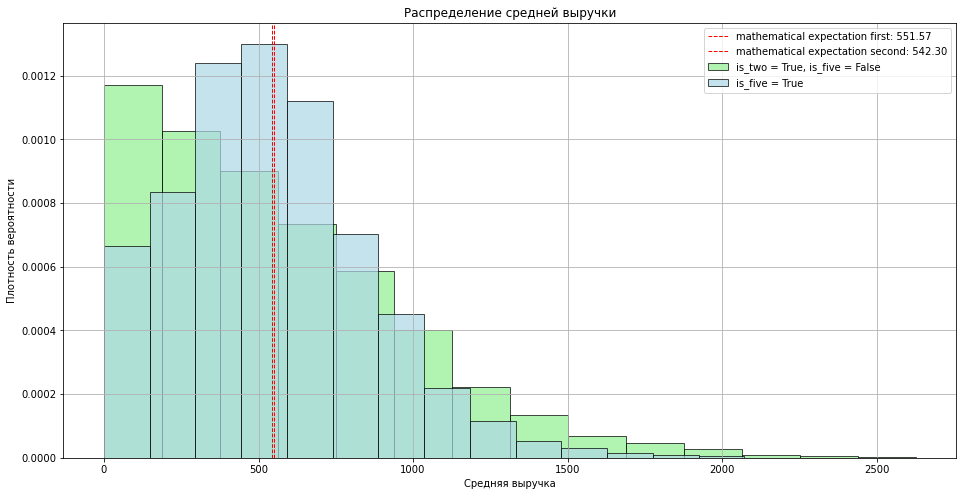

In [141]:
# Визуализируем распределение пользователей для других групп, но используя ту же визуализацию

plt.figure(figsize = (16, 8))

# Правило Стерджеса для оптимального количества бинов
k_f = round(1 + (3.322 * math.log10(df_profile.loc[(df_profile['is_two'] == True) & (df_profile['is_five'] == False)]['avg_rub'].size)))
k_t = round(1 + (3.322 * math.log10(df_profile.loc[df_profile['is_five'] == True]['avg_rub'].size)))
k = round((k_f + k_t) / 2)

# Вычсляем математические ожидания
mean_first = df_profile.loc[(df_profile['is_two'] == True) & (df_profile['is_five'] == False)]['avg_rub'].mean()
mean_second = df_profile.loc[df_profile['is_five'] == True]['avg_rub'].mean()

df_profile.loc[(df_profile['is_two'] == True) & (df_profile['is_five'] == False)]['avg_rub'].plot(
    kind = 'hist',
    bins = k,
    color = 'lightgreen',
    edgecolor = 'black',
    title = 'Распределение средней выручки',
    alpha = 0.7,
    density = True,
    label = 'is_two = True, is_five = False')

plt.axvline(mean_first, color='red', linestyle='--', linewidth=1, 
           label=f'mathematical expectation first: {mean_first:.2f}')

df_profile.loc[df_profile['is_five'] == True]['avg_rub'].plot(
    kind = 'hist',
    bins = k,
    color = 'lightblue',
    edgecolor = 'black',
    title = 'Распределение средней выручки',
    alpha = 0.7,
    density = True,
    label = 'is_five = True')

plt.axvline(mean_second, color='red', linestyle='--', linewidth=1, 
           label=f'mathematical expectation second: {mean_second:.2f}')


plt.legend()
plt.xlabel('Средняя выручка')
plt.ylabel('Плотность вероятности')
plt.grid()

plt.show()

### Замечание
Для сравнения средней выручки по каждой категории найдем математическое ожидание.

### Промежуточный вывод
Хоть математические ожидания обеих групп получились довольно близкими по значению, мы видим, что распределение имеет разный вид на гистограмме, соответственно поведение пользователей в данных группах отличается. Значение средней выручки для обеих групп действительно примерно равно, но в группах преобладают разные самые популярные стоимомти заказов. В первой группе значения расположены чаще всего в [0 ; 600], во второй же группе значения чаще всего расположены в [250; 750].

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

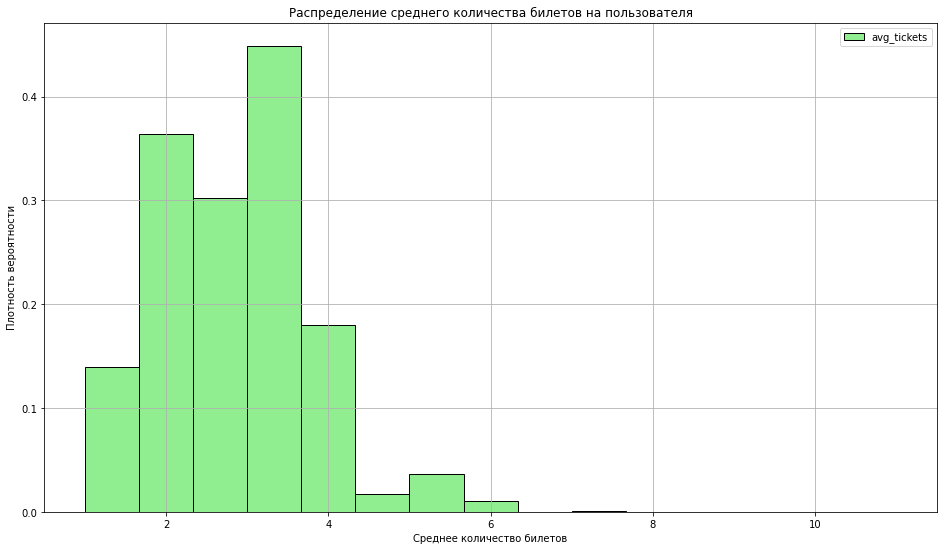

In [142]:
# Визуализируем распределение пользователей по среднему количеству билетов

plt.figure(figsize = (16, 9))

# Правило  Стерджеса
k = round(1 + (3.322 * math.log10(df_profile['avg_tickets'].size)))

df_profile['avg_tickets'].plot(
    kind = 'hist',
    bins = k,
    color = 'lightgreen',
    edgecolor = 'black',
    title = 'Распределение среднего количества билетов на пользователя',
    density = True)

plt.legend()
plt.xlabel('Среднее количество билетов')
plt.ylabel('Плотность вероятности')
plt.grid()

plt.show()

### Промежуточный вывод
Мы визуализировали распределение среднего количества билетов на пользователя. Мы видим, что гистограмме характерны некоторые скачки, если поэкспериментировать с количеством корзин для гистограммы, то можно явно увидеть, что чаще всего встречаются значения с целым числом, т.е. 1, 2, 3, 4. Такое распределение нам говорит о том, что пользователи чаще всего покупают 1 - 4 билета и преимущественно либо всегда одно и то же количество, либо делают заказ только единожды. 

In [143]:
# Сгруппируем данные по сегментам

first_segment = df_profile.loc[(df_profile['avg_tickets'] >= 1) & (df_profile['avg_tickets'] <= 2)]
second_segment = df_profile.loc[(df_profile['avg_tickets'] >= 2) & (df_profile['avg_tickets'] <= 3)]
third_segment = df_profile.loc[(df_profile['avg_tickets'] >= 3) & (df_profile['avg_tickets'] <= 5)]
fourth_segment = df_profile.loc[df_profile['avg_tickets'] >= 5]

In [144]:
# Количество пользователей в каждом сегменте

print(f"Количество пользователей в первом сегменте: {first_segment.shape[0]}, [1;2]")
print(f"Количество пользователей во втором сегменте: {second_segment.shape[0]}, [2;3]")
print(f"Количество пользователей в третьем сегменте: {third_segment.shape[0]}, [3;5]")
print(f"Количество пользователей в четвертом сегменте: {fourth_segment.shape[0]}, от 5-ти")

Количество пользователей в первом сегменте: 6149, [1;2]
Количество пользователей во втором сегменте: 12874, [2;3]
Количество пользователей в третьем сегменте: 9384, [3;5]
Количество пользователей в четвертом сегменте: 661, от 5-ти


In [145]:
# Доля пользователей, которые совершили повторный заказа

print(f"Доля пользователей, которые совершили повторный заказ в первом сегменте: {round(first_segment['is_two'].sum() / first_segment.shape[0], 4)}")
print(f"Доля пользователей, которые совершили повторный заказ во втором сегменте: {round(second_segment['is_two'].sum() / second_segment.shape[0], 4)}")
print(f"Доля пользователей, которые совершили повторный заказ в третьем сегменте: {round(third_segment['is_two'].sum() / third_segment.shape[0], 4)}")
print(f"Доля пользователей, которые совершили повторный заказ в четвертом сегменте: {round(fourth_segment['is_two'].sum() / fourth_segment.shape[0], 4)}")

Доля пользователей, которые совершили повторный заказ в первом сегменте: 0.4009
Доля пользователей, которые совершили повторный заказ во втором сегменте: 0.6071
Доля пользователей, которые совершили повторный заказ в третьем сегменте: 0.5157
Доля пользователей, которые совершили повторный заказ в четвертом сегменте: 0.1876


In [146]:
data_segment = {
    'segments' : ['first_segment', 'second_segment', 'third_segment', 'fourth_segment'],
    'size' : [first_segment.shape[0], second_segment.shape[0], third_segment.shape[0], fourth_segment.shape[0]]
}

df_segment_size = pd.DataFrame(data_segment)
df_segment_size

,segments,size
0,first_segment,6149
1,second_segment,12874
2,third_segment,9384
3,fourth_segment,661


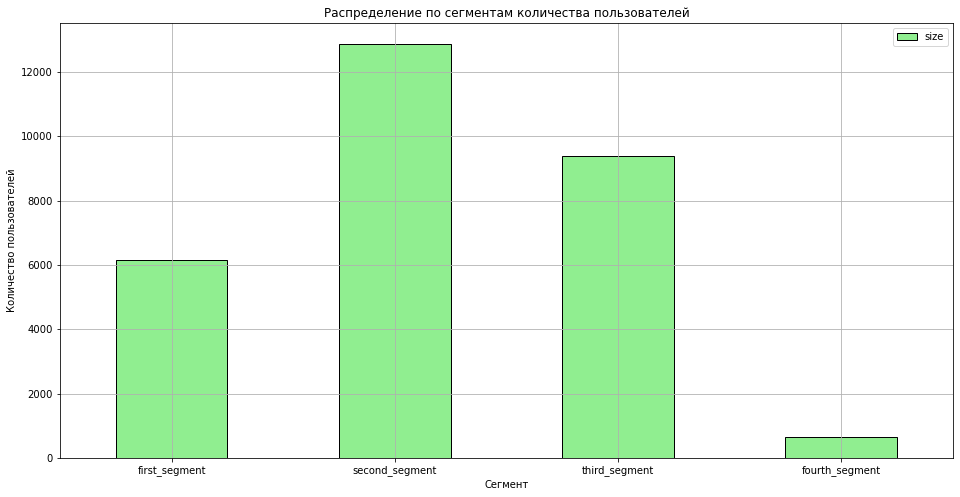

In [147]:
# Визуализируем распределение

df_segment_size.plot(
    kind = 'bar',
    x = 'segments',
    y = 'size',
    figsize = (16, 8),
    color = 'lightgreen',
    edgecolor = 'black',
    title = 'Распределение по сегментам количества пользователей')

plt.grid()
plt.xlabel('Сегмент')
plt.ylabel('Количество пользователей')
plt.xticks(rotation = 0)


plt.show()

### Промежуточный вывод

* По столбчатой диаграмме может оценить количество пользователей в каждом сегменте. Видим, что пользователи распределены не равномерно, больше всего пользователеей во втором сегменте, что соответсвует 2 - 3 билетам в среднем. Далее идет третий сегмент, а после него первый. В четвером сегменте совсем мало людей, что было предсказуемо.
* Аномально высокой доли повторных покупок среди сегментов не наблюдается, можем отметить, что лидер по этому показателю второй сегмент, который имеет показатель `0.6`, первый и третий сегмент уступают по этому показтелю. Однако четвертый сегмент аномальный, так как имеет очень низкий показатель по повторным покупкам, всего `0.19`.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [148]:
df_profile

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets,avg_between_time,is_two,is_five
0,57ef0a1905ac488,2024-06-01,2024-09-26,mobile,лесодальний_край,билеты_в_руки,театр,4,797.937500,2.5,39 days 01:49:09,True,False
1,8b9ff6a430865fb,2024-06-01,2024-10-12,desktop,малиновоярский_округ,билеты_без_проблем,концерты,9,783.963318,2.0,16 days 17:29:24,True,True
2,520a8c0f376287b,2024-06-01,2024-06-01,mobile,луговая_область,билеты_без_проблем,другое,1,71.570000,1.0,NaT,False,False
3,a044b39568cedcb,2024-06-01,2024-10-25,desktop,каменевский_регион,билеты_без_проблем,концерты,2,1062.635010,2.5,146 days 15:06:11,True,False
4,c9f1f9e2967b769,2024-06-01,2024-06-01,mobile,берёзовская_область,билеты_без_проблем,другое,1,26.219999,2.0,NaT,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20707,f0dac51f739f59f,2024-10-31,2024-10-31,mobile,солнечнореченская_область,облачко,концерты,1,380.299988,1.0,NaT,False,False
20708,176b51ad2feb561,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,726.520020,3.0,NaT,False,False
20709,988e4859d820cb5,2024-10-31,2024-10-31,mobile,травяная_область,билеты_в_руки,театр,1,19.610001,2.0,NaT,False,False
20710,e994c1637905fe5,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,94.610001,1.0,NaT,False,False


In [149]:
# Подготовим датафрейм для задачи

df_dw = df_profile[['user_id', 'first_order_dt', 'is_two']].copy()
df_dw

,user_id,first_order_dt,is_two
0,57ef0a1905ac488,2024-06-01,True
1,8b9ff6a430865fb,2024-06-01,True
2,520a8c0f376287b,2024-06-01,False
3,a044b39568cedcb,2024-06-01,True
4,c9f1f9e2967b769,2024-06-01,False
...,...,...,...
20707,f0dac51f739f59f,2024-10-31,False
20708,176b51ad2feb561,2024-10-31,False
20709,988e4859d820cb5,2024-10-31,False
20710,e994c1637905fe5,2024-10-31,False


In [150]:
# Найдем день недели по дате первого заказа

df_dw['day_week'] = df_dw['first_order_dt'].dt.day_name()
df_dw

,user_id,first_order_dt,is_two,day_week
0,57ef0a1905ac488,2024-06-01,True,Saturday
1,8b9ff6a430865fb,2024-06-01,True,Saturday
2,520a8c0f376287b,2024-06-01,False,Saturday
3,a044b39568cedcb,2024-06-01,True,Saturday
4,c9f1f9e2967b769,2024-06-01,False,Saturday
...,...,...,...,...
20707,f0dac51f739f59f,2024-10-31,False,Thursday
20708,176b51ad2feb561,2024-10-31,False,Thursday
20709,988e4859d820cb5,2024-10-31,False,Thursday
20710,e994c1637905fe5,2024-10-31,False,Thursday


In [151]:
# Вычислим сколько пользователей в каждой категории

df_dw_agg = df_dw.groupby('day_week')['user_id'].count().reset_index(name = 'count_users')

df_dw_agg

,day_week,count_users
0,Friday,3158
1,Monday,2809
2,Saturday,3118
3,Sunday,2637
4,Thursday,3023
5,Tuesday,3009
6,Wednesday,2958


In [152]:
# Вычислим долю пользователей в каждой категории, которые совершили повторный заказ

df_dw_agg = df_dw_agg.merge(df_dw.groupby('day_week')['is_two'].sum().reset_index(name = 'count_is_two'), on = 'day_week', how = 'left')
df_dw_agg

,day_week,count_users,count_is_two
0,Friday,3158,1847
1,Monday,2809,1729
2,Saturday,3118,1881
3,Sunday,2637,1528
4,Thursday,3023,1761
5,Tuesday,3009,1803
6,Wednesday,2958,1803


In [153]:
# Добавим в рабочий датафрейм признак с отношением

df_dw_agg['dw_relative'] = round(df_dw_agg['count_is_two'] / df_dw_agg['count_users'], 4)
df_dw_agg

,day_week,count_users,count_is_two,dw_relative
0,Friday,3158,1847,0.5849
1,Monday,2809,1729,0.6155
2,Saturday,3118,1881,0.6033
3,Sunday,2637,1528,0.5794
4,Thursday,3023,1761,0.5825
5,Tuesday,3009,1803,0.5992
6,Wednesday,2958,1803,0.6095


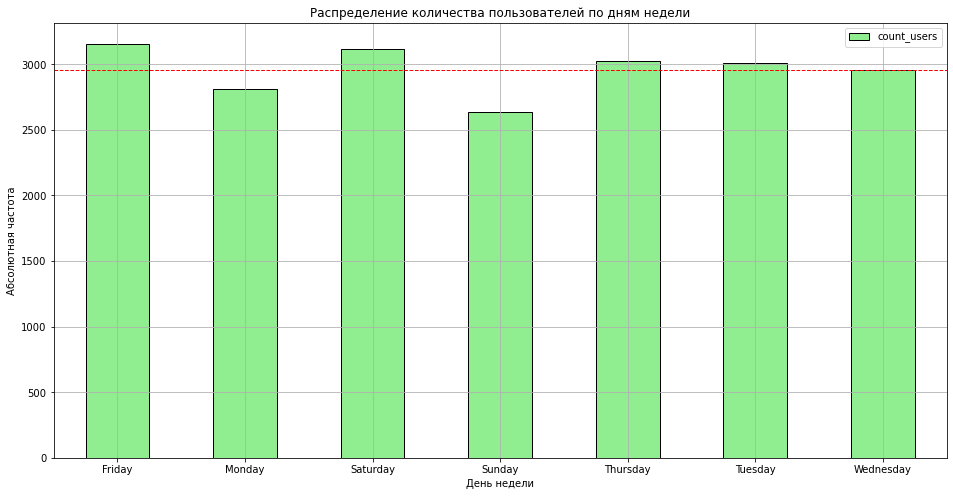

In [154]:
# Визуализируем абсолютную частоту для каждого дня недели

mean_value = df_dw_agg['count_users'].mean()

df_dw_agg.plot(
    kind = 'bar',
    x = 'day_week',
    y = 'count_users',
    figsize = (16, 8),
    color = 'lightgreen',
    edgecolor = 'black',
    title = 'Распределение количества пользователей по дням недели')

# Добавляем линию среднего значения
plt.axhline(y = mean_value, color= 'red', linestyle='--', linewidth=1)

plt.grid()
plt.xlabel('День недели')
plt.ylabel('Абсолютная частота')
plt.xticks(rotation = 0)

plt.show()

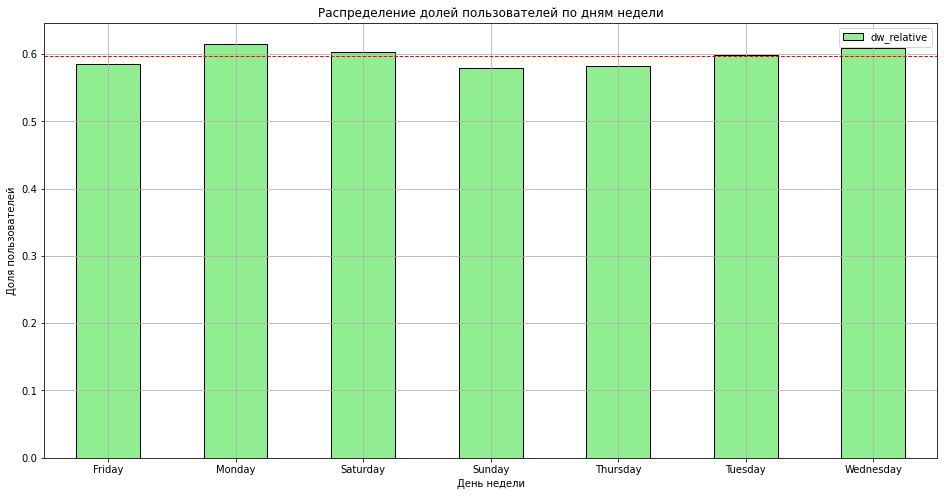

In [155]:
# Визуализируем долю пользователей, которые совершили повторный заказ для каждого дня недели

mean_value = df_dw_agg['dw_relative'].mean()

df_dw_agg.plot(
    kind = 'bar',
    x = 'day_week',
    y = 'dw_relative',
    figsize = (16, 8),
    color = 'lightgreen',
    edgecolor = 'black',
    title = 'Распределение долей пользователей по дням недели')

# Добавляем линию среднего значения
plt.axhline(y = mean_value, color= 'red', linestyle='--', linewidth=1)

plt.grid()
plt.xlabel('День недели')
plt.ylabel('Доля пользователей')
plt.xticks(rotation = 0)

plt.show()

### Промежуточный вывод
Мы проанализировали и визуализировали данные, теперь на стобчатой диаграмме можно явно увидеть, что доля повторных заказов практически слабо зависит от дня недели. Действительно, в некоторые дни недели, такие как воскресенье, четверг и пятница, доля возврата клиентов немного меньше, на `1 - 2 %`, от среднего значения. Остальные же дни недели находятся или на уровне среднего значения или превышают его на `1 - 2 %`. Самая большая разница в значения между понедельником и воскресеньем.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [156]:
# Датафрейм для первой группы
df_first_group = df_profile.loc[(df_profile['is_two'] == True) & (df_profile['is_five'] == False)][['user_id', 'total_order_count', 'avg_between_time']].copy()
df_first_group

,user_id,total_order_count,avg_between_time
0,57ef0a1905ac488,4,39 days 01:49:09
3,a044b39568cedcb,2,146 days 15:06:11
20,b415dc6727f4bb0,2,110 days 12:36:52
28,3c209fca771e766,3,0 days 00:57:28
35,2d97f59b3a8eebf,2,0 days 00:03:19
...,...,...,...
20697,fe049d677ba58aa,4,0 days 00:05:22
20698,f1098cd40e4fa16,3,0 days 00:02:44
20699,74986c83fc69b53,3,0 days 00:06:40
20705,e8e39397f5f1657,3,0 days 00:01:36


In [157]:
# Датафрейм для второй группы
df_second_group = df_profile.loc[df_profile['is_five'] == True][['user_id', 'total_order_count', 'avg_between_time']].copy()
df_second_group

,user_id,total_order_count,avg_between_time
1,8b9ff6a430865fb,9,16 days 17:29:24
5,800f3d023f98a32,18,8 days 17:48:53
7,fbc938ceaef1c45,13,11 days 12:01:30
8,a1e43aa4d95bb1f,7,11 days 01:23:44
9,6588dd344ffce4a,23,6 days 21:34:59
...,...,...,...
20688,2b0242bf621cd75,16,0 days 00:01:33
20690,360fb2b510e754a,15,0 days 00:01:14
20692,37215afc6eb8995,19,0 days 00:01:21
20703,4b59da2ac8cf539,5,0 days 00:01:06


### Замечание
Данные с типом данных `timedelta64[ns]` не смогут уместить в себя все результаты вычисления, если оставить их в полном виде. Чтобы избежать ошибок переполнения оставим только дни.

In [158]:
# Извлекаем только дни из timedelta
df_first_group['avg_between_days'] = df_first_group['avg_between_time'].dt.days

# Вычисляем взвешенное среднее для дней
weighted_avg_days_first = (df_first_group['avg_between_days'] * (df_first_group['total_order_count'] - 1)).sum() / (df_first_group['total_order_count'] - 1).sum()

print(f"Взвешенное среднее для первой группы: {weighted_avg_days_first:.2f} дней")

Взвешенное среднее для первой группы: 19.61 дней


In [159]:
# Извлекаем только дни из timedelta
df_second_group['avg_between_days'] = df_second_group['avg_between_time'].dt.days

# Вычисляем взвешенное среднее для дней
weighted_avg_days_second = (df_second_group['avg_between_days'] * (df_second_group['total_order_count'] - 1)).sum() / (df_second_group['total_order_count'] - 1).sum()

print(f"Взвешенное среднее для второй группы: {weighted_avg_days_second:.2f} дней")

Взвешенное среднее для второй группы: 8.70 дней


### Промежуточный вывод
Мы вычислили среднее время между заказами для обеих групп пользователей. Можно прийти к выводу, что пользователи, которые совершают заказы с меньшим промежутуоком времени, они же чаще и совершают повторные заказы. Это может быть связано с тем, что в таких ситуация билеты покупаются в несколько итераций, а не за один раз. Возможно такие пользователи являются постоянными клиентами.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [160]:
# Создадим датафрейм для преобразований
df_profile_fixed = df_profile[['first_order_dt', 'last_order_dt', 'first_device', 'first_region', 'first_service', 'first_event_type', 'total_order_count', 'avg_rub', 'avg_tickets', 'avg_between_time', 'is_two', 'is_five']].copy()
df_profile_fixed

,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets,avg_between_time,is_two,is_five
0,2024-06-01,2024-09-26,mobile,лесодальний_край,билеты_в_руки,театр,4,797.937500,2.5,39 days 01:49:09,True,False
1,2024-06-01,2024-10-12,desktop,малиновоярский_округ,билеты_без_проблем,концерты,9,783.963318,2.0,16 days 17:29:24,True,True
2,2024-06-01,2024-06-01,mobile,луговая_область,билеты_без_проблем,другое,1,71.570000,1.0,NaT,False,False
3,2024-06-01,2024-10-25,desktop,каменевский_регион,билеты_без_проблем,концерты,2,1062.635010,2.5,146 days 15:06:11,True,False
4,2024-06-01,2024-06-01,mobile,берёзовская_область,билеты_без_проблем,другое,1,26.219999,2.0,NaT,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
20707,2024-10-31,2024-10-31,mobile,солнечнореченская_область,облачко,концерты,1,380.299988,1.0,NaT,False,False
20708,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,726.520020,3.0,NaT,False,False
20709,2024-10-31,2024-10-31,mobile,травяная_область,билеты_в_руки,театр,1,19.610001,2.0,NaT,False,False
20710,2024-10-31,2024-10-31,mobile,североярская_область,мой_билет,концерты,1,94.610001,1.0,NaT,False,False


In [161]:
# Преобразуем данные для работы с датой и временем
df_profile_fixed['avg_between_time'] = df_profile_fixed['avg_between_time'].dt.total_seconds()

# Преобразуем в числовой формат timestamp в днях
df_profile_fixed['first_order_dt'] = (df_profile_fixed['first_order_dt'] - pd.Timestamp('2020-01-01')).dt.days
df_profile_fixed['last_order_dt'] = (df_profile_fixed['last_order_dt'] - pd.Timestamp('2020-01-01')).dt.days

df_profile_fixed

,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets,avg_between_time,is_two,is_five
0,1613,1730,mobile,лесодальний_край,билеты_в_руки,театр,4,797.937500,2.5,3376149.0,True,False
1,1613,1746,desktop,малиновоярский_округ,билеты_без_проблем,концерты,9,783.963318,2.0,1445364.0,True,True
2,1613,1613,mobile,луговая_область,билеты_без_проблем,другое,1,71.570000,1.0,NaN,False,False
3,1613,1759,desktop,каменевский_регион,билеты_без_проблем,концерты,2,1062.635010,2.5,12668771.0,True,False
4,1613,1613,mobile,берёзовская_область,билеты_без_проблем,другое,1,26.219999,2.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
20707,1765,1765,mobile,солнечнореченская_область,облачко,концерты,1,380.299988,1.0,NaN,False,False
20708,1765,1765,mobile,североярская_область,мой_билет,концерты,1,726.520020,3.0,NaN,False,False
20709,1765,1765,mobile,травяная_область,билеты_в_руки,театр,1,19.610001,2.0,NaN,False,False
20710,1765,1765,mobile,североярская_область,мой_билет,концерты,1,94.610001,1.0,NaN,False,False


In [162]:
# Проверим типы данных

df_profile_fixed.dtypes

first_order_dt          int64
last_order_dt           int64
first_device         category
first_region         category
first_service        category
first_event_type     category
total_order_count       int64
avg_rub               float32
avg_tickets           float64
avg_between_time      float64
is_two                   bool
is_five                  bool
dtype: object

In [163]:
# Построим матрицу корреляций

interval_cols = ['first_order_dt', 'last_order_dt', 'total_order_count', 'avg_rub', 'avg_tickets', 'avg_between_time']

correlation_matrix = df_profile_fixed.phik_matrix(interval_cols = interval_cols)
correlation_matrix

,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_order_count,avg_rub,avg_tickets,avg_between_time,is_two,is_five
first_order_dt,1.000000,0.941488,0.031125,0.344478,0.210789,0.149703,0.423890,0.210135,0.178567,0.403307,0.391900,0.477318
last_order_dt,0.941488,1.000000,0.017592,0.256226,0.155216,0.092460,0.424868,0.190021,0.174155,0.253061,0.436188,0.502646
first_device,0.031125,0.017592,1.000000,0.112848,0.083239,0.060761,0.052058,0.077230,0.056741,0.017350,0.032630,0.037790
first_region,0.344478,0.256226,0.112848,1.000000,0.696534,0.505928,0.033813,0.358608,0.171867,0.104061,0.072436,0.069089
first_service,0.210789,0.155216,0.083239,0.696534,1.000000,0.589847,0.039425,0.387637,0.066067,0.050679,0.048858,0.058197
first_event_type,0.149703,0.092460,0.060761,0.505928,0.589847,1.000000,0.034496,0.334015,0.097203,0.052199,0.032332,0.024755
total_order_count,0.423890,0.424868,0.052058,0.033813,0.039425,0.034496,1.000000,0.264200,0.295308,0.490761,0.719476,0.986158
avg_rub,0.210135,0.190021,0.077230,0.358608,0.387637,0.334015,0.264200,1.000000,0.453608,0.113279,0.294391,0.293245
avg_tickets,0.178567,0.174155,0.056741,0.171867,0.066067,0.097203,0.295308,0.453608,1.000000,0.092906,0.378647,0.336887
avg_between_time,0.403307,0.253061,0.017350,0.104061,0.050679,0.052199,0.490761,0.113279,0.092906,1.000000,NaN,0.446216


In [164]:
# Выведем значения корреляции для признака total_order_count
correlation_with_orders = correlation_matrix['total_order_count'].sort_values(ascending = False)
correlation_with_orders

total_order_count    1.000000
is_five              0.986158
is_two               0.719476
avg_between_time     0.490761
last_order_dt        0.424868
first_order_dt       0.423890
avg_tickets          0.295308
avg_rub              0.264200
first_device         0.052058
first_service        0.039425
first_event_type     0.034496
first_region         0.033813
Name: total_order_count, dtype: float64

### Промежуточный вывод
Видим очень сильную корреляцию признака `total_order_count` c признаком `is_five`. Также можем наблюдать сильную корреляцию с признаком `is_two`. Далее идут признаки где есть умеренная корреляция это: `avg_between_time`, `first_order_dt`, `last_order_dt`, `avg_tickets`, `avg_rub`. Остальные признаки показывают аномально низкую корреляцию, которая примерно равна нулю.

In [165]:
# Проверим однородность данных в total_order_count
df_profile_fixed['total_order_count'].value_counts(normalize = True).sort_values(ascending = False)

1     0.403631
2     0.172364
3     0.104915
4     0.067642
5     0.046736
6     0.033990
7     0.026072
8     0.021871
9     0.018443
10    0.013808
11    0.011298
12    0.009656
14    0.007484
13    0.007387
16    0.006663
15    0.005987
17    0.005070
18    0.004007
21    0.003814
19    0.003476
22    0.003283
20    0.003235
24    0.003187
25    0.002849
23    0.002800
26    0.002559
27    0.002462
28    0.002173
29    0.001786
30    0.001352
Name: total_order_count, dtype: float64

### Замечание
Действительно в данных преобладает одно значение, значит следует проанализировать, разбив на сегменты.

In [166]:
# Создаем сегменты
df_profile_fixed['order_segment'] = pd.cut(
    df_profile_fixed['total_order_count'],
    bins=[0, 1, 4, float('inf')],
    labels=['1_заказ', '2-4_заказа', '5+_заказов'],
    right=True
)
    
# Удаляем исходный total_order_count для корреляции
df_segmented = df_profile_fixed.drop('total_order_count', axis=1)

df_segmented.dtypes
    
# Проведем корреляционный анализ с сегментами
interval_cols = ['first_order_dt', 'last_order_dt','avg_rub', 'avg_tickets', 'avg_between_time']

segmented_matrix_correlation = df_segmented.phik_matrix(interval_cols = interval_cols)
segment_correlations = segmented_matrix_correlation['order_segment'].sort_values(ascending = False)
    
segment_correlations

is_two              1.000000
is_five             1.000000
order_segment       1.000000
last_order_dt       0.451595
first_order_dt      0.425832
avg_between_time    0.374245
avg_tickets         0.357830
avg_rub             0.298002
first_region        0.107739
first_service       0.080287
first_event_type    0.040771
first_device        0.015567
Name: order_segment, dtype: float64

### Замечание
Можем обратить внимание, что показатели действительно изменились, теперь корреляция прослживается более ярко.

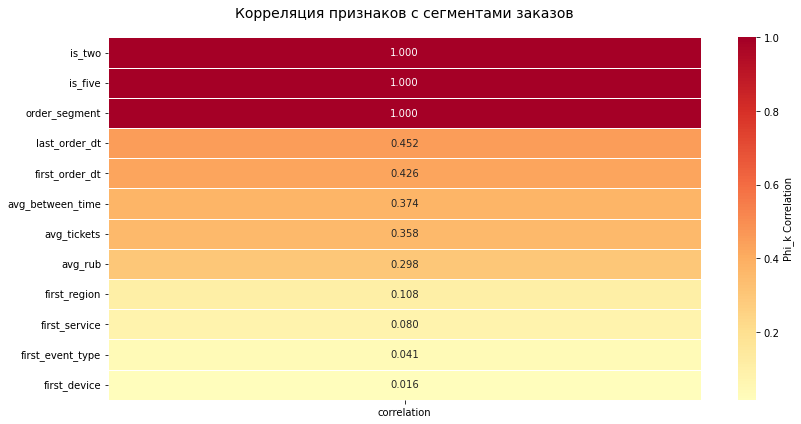

In [167]:
# Визуализация с помощью тепловой карты

# Датафрейм для тепловой карты
corr_df = segment_correlations.to_frame('correlation')

plt.figure(figsize=(12, 6))

sns.heatmap(corr_df, 
            annot=True,  # показываем числа в ячейках
            fmt='.3f', # формат чисел
            cmap='RdYlBu_r', # цветовая схема
            center=0, # центр цветовой шкалы
            cbar_kws={'label': 'Phi_k Correlation'},
            linewidths=0.5,
            linecolor='white')

plt.title('Корреляция признаков с сегментами заказов', fontsize=14, pad=20)
plt.tight_layout()

plt.show()

### Промежуточный вывод
С помощью тепловой карты можно явно понять какие из признаков коррелирую сильно с количеством заказов, а какие практические не коррелируют. С количеством заказов напрямую связаны признаки `is_two`, `is_five`, что вполне логично и предсказуемо, теперь после разбития на сегменты корреляция наблюдается полная. Также достаточную корреляцию имеют следующие признаки: `last_order_dt`, `first_order_dt`, `avg_between_time`, `avg_tickets`, `avg_rub`. Данные показали, что данные по количеству заказов непосредственно влияют на признаки, которые были перечислены выше.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

## Вывод
### Информация о данных

* Для анализа данных использовалась большое количество датафреймов, мы начали с вышрузки данных из БД с помощью SQL-запроса. Получив необходимые данные для каждого заказа, мы предобработали данные: удалили дубликаты, обработали пропуски, настроили типы данных. К полученным данным была присоединена csv_таблица, которая содержала курс тенге на каждую дату, с помощью этих данных мы смогли создать признак для работы только с рублями. Фильтрация данных производилась неоднократно по различным признакам, чтобы исключить аномальные данные. Также данные визуализировались для наглядности анализа. После подготовки данных по заказам мы создали датафрейм - профиль пользователя. Здесь для каждого уникального пользователя мы нашли важные показатели, по которым проводили дальнейший анализ. Для данного датафрейма ткже была проведена фильтрация, чтобы не допустить аномальных значений. 


* Подготовив данные, мы перешли к исследовательскому анализу данных, где увидели взаимосвязи между ключевыми показателями и их корреляции.

### Основные результаты анализа

Мы выяснили следующее:
* После составления датафрейма - профиль пользователя и фильтрации выбросов в нашей выборке оказлось `20712` уникальных пользователей.
* По числу заказов пользователи распределены неравномерно, пользователей, которые совершили только один заказа около `40%`. Мы изучили поведение пользователей в разрезе различных признаков. Мы узнали сколько пользователей относятся к различным категориям по первому заказу. Таким образом мы выснили, что концерты самыйй популярный тип мероприятий для первого заказа, а телефоны используется в четырех из пяти случаев во время выполнения первого заказа. Также мы нашли самые популярные регионы и сервисы для выполнения первого заказа.
* Также мы проанализировали какие признаки связаны с возвратом пользователей на платформу. Таким образом категория `спорт` имеет самый маленький процент возврата пользователей, а категория `выставки` самый высокий. Тип устройства практически не влияет на возврат пользователя, однако `mobile` показывает отношение немного лучше. Аналогичный анализ мы провели также для регионов и для сервисов. Мы визуализировали результаты, чтобы наглядно увидеть разницу между категориями. Таким образом, мы выяснили, что категории влияют на возврат клиентов в различных признаках.
* Мы изучили распределение средней выручки пользователей в зависимости от того совершали ли они повторный заказ, изобразив плотность вероятности обоих сегментов с помощью гистограмм. Аналогично мы сравнили группы, где пользователи совершили 2-4 заказа и 5 и более, для таких групп распределения плотности отличаются, но математическое ожидание очень близкое.
* Мы выяснили, что чаще всего люди преобретают в среднем одно и то же количество билетов, это может быть связано с тем, что заказ единственный, или пользователь покупает одно и то же количество билетов, например 3, т.к. он ходит вместе с семьей и всемье 3 человека.
* Пользователи чаще всего преобретают 2-3 билета в среднем. Это самый крупный сегмент.
* Можно обратить внимание, что пользователи редко совершают первый заказ в понедельник, но при этом, в понедельник самый высокий показатель по вероятности повторного заказа.
* День недели влияет на вероятность совершения первого заказа, но не внушительно.
* Мы заметили, что пользователи совершают повторные заказы чащея, если совершают их стабильно с меньшим промежутком времени. Или есть гипотеза, что много билетов покупалось одним пользователем в несколько итераций, но это требует дополнительного анализа.
* Мы построили матрицу корреляций, проанализировали, что особенно влияет на количество заказов. Имеет серьезную корреляцию время первого и последнего заказа, т.е. чем дольше пользователь пользуется сервисом, тем больше он заказов совершает. Это значит, что требуется поддерживать интерес пользователя к платформе. Также есть корреляция со средним временем между заказами, можно сделать вывод, что стоит учитывать насколько часто пользователь совершает заказы, чтобы он совершал больше заказов. Есть корреляция со средним количеством билетов, т.е. количество заказов пользователя зависит от того сколько билетов в среднем он покупает. Также есть кореляция со средней стоимостью заказа, от этого фактора тоже зависит количество заказов пользователя, можно ,например, чаще предлагать какие-то специальные предложения пользователям, которые уже совершили один заказа, чтобы заинтересовать их в использовании платформы. Количество заказов практически не зависит от первого региона, сервиса, устройства или мероприятия. 
* Основной вывод, которые можно сделать из корреляции данных: вероятность возвращения пользователя напрямую завивист от платформы, т.е. Яндекс Афиши, если пользователя все удовлетовряет, то он делает заказы чаще независимо от внешних факторов.

## Рекомендации
Мы выяснили, что многие пользователи совершают только один заказа, это может свидетельствовать о том, что комания делает много специальных предложений новым клиентам. Основная задача на данном этапе - удержать клиентов, т.е. совершить действия, которые простимулируют людей совершать повторные заказы.


**Предложения:**
* Чаще прделагать пользователям типы мероприятия, которые они выбирали при первом заказе, а также предлагать специальные предложения на такие мероприятия. Однако как мы уже сказали тип мероприятия не влияет на количество заказов, но все равно имеет значение для возвращения пользователя на платформу.
* Можно сделать акцент на рекламу по понедельникам, например в часы, когда люди едут на работу или с работы, т.к. в этот день недели пришедшие пользователи совершают повторные заказы чаще.
* Проанализировать более подробно зависимость признаков, которые коррелируют с количеством заказов.
* Можно для пользователей, которые совершили первый заказа делают специальное предложение на второй.
* Можно дополнительно осведомлять пользователей, которые совершили один заказ о специальных предложениях на второй заказ.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**